In [1]:
import pandas as pd
import numpy as np
from statics import *
import seaborn as sns
import matplotlib.pyplot as plt
# https://data.crunchbase.com/docs/data-dictionary

In [2]:
pd.set_option('display.max_columns', None)  # Show all columns when displaying DataFrames

In [3]:
# load raw data
org_df_raw = pd.read_csv('20251012_bulk_export/organizations.csv')
org_des_df_raw = pd.read_csv('20251012_bulk_export/organization_descriptions.csv')
fund_rounds_df_raw = pd.read_csv('20251012_bulk_export/funding_rounds.csv')
llm_cls_df_raw = pd.read_csv('crunchbase_companies_final.csv')

In [4]:
ipo_df_raw = pd.read_csv('20251012_bulk_export/ipos.csv')
acq_df_raw = pd.read_csv('20251012_bulk_export/acquisitions.csv')

# narrow down the scope
- North America (CAN + USA)
- Company roles: please keep only “company” and “company,investor”  (I.e., exclude “school”, “investor”, “school,company”, etc.)
- Founding date (founded_on) 2005 or later (if missing, you can keep the observation for now)
- If company “status” is closed: closing date (closed_on) 2019 or late

In [5]:
org_df = org_df_raw[org_df_raw['country_code'].isin(['USA', 'CAN'])]  # filter to US and Canada only
org_df = org_df[org_df['roles'].isin(['company', 'company,investor'])]  # filter to keep only organizations that are not investors
# fileter on founded_on >=2005-01-01
org_df['founded_on'] = pd.to_datetime(org_df['founded_on'], errors='coerce')
org_df = org_df[org_df['founded_on'] >= '2005-01-01']
# exclude companies with  status 'closed' and close_on before 2019-01-01
org_df['close_on'] = pd.to_datetime(org_df['closed_on'], errors='coerce')
org_df = org_df[~((org_df['status'] == 'closed') & (org_df['close_on'] < '2019-01-01'))]

# add description info 
org_df = pd.merge(org_des_df_raw[['uuid','description']], org_df, on='uuid',how='right')


In [6]:
acq_df = acq_df_raw.drop(columns=['uuid'])
acq_df = acq_df.rename(columns={'acquiree_uuid': 'uuid', 'price_usd': 'acquired_valued_at_usd'})
acq_df = acq_df[['uuid', 'acquired_on', 'acquired_valued_at_usd']]
# Sort by acquired_on and keep the first one (in case of multiple acquisition records)
acq_df = acq_df.sort_values(by='acquired_on').drop_duplicates(subset=['uuid'], keep='first')


ipo_df = ipo_df_raw.drop(columns=['uuid'])
ipo_df = ipo_df.rename(columns={'org_uuid': 'uuid', 'valuation_price_usd': 'ipo_valued_at_usd'})
ipo_df = ipo_df[['uuid', 'went_public_on', 'ipo_valued_at_usd']]
# sort by went_public_on and keep the first one (in case of multiple IPO records)
ipo_df = ipo_df.sort_values(by='went_public_on').drop_duplicates(subset=['uuid'], keep='first')

# merge acquisition and ipo info
org_df = pd.merge(org_df, acq_df, on='uuid', how='left')
org_df = pd.merge(org_df, ipo_df, on='uuid', how='left') 

In [7]:
cats = org_df['category_list']
cats_exploded = cats.str.split(',').explode().str.strip()
all_categories = cats_exploded.dropna().unique()
len(all_categories)

798

- The status in the original data represent latest status 
- what we need is the exits status, so I change the status based on earlier exist date and exist type 
- compute age by exits date - founded date 

In [8]:
# process status 
# add age of companies based on founded_on date and current date
org_df['founded_on'] = pd.to_datetime(org_df['founded_on'], errors='coerce')
org_df['closed_on'] = pd.to_datetime(org_df['closed_on'], errors='coerce')
org_df['went_public_on'] = pd.to_datetime(org_df['went_public_on'], errors='coerce')
org_df['acquired_on'] = pd.to_datetime(org_df['acquired_on'], errors='coerce')

# fix data quality issue - correct status based on exit dates (we call exits status)
def fix_status(row):
    # If status is 'operating', keep it as is
    if row['status'] == 'operating':
        return row['status']
    
    # For non-operating or null status, check exit dates
    dates = {}
    if pd.notnull(row['closed_on']):
        dates['closed'] = row['closed_on']
    if pd.notnull(row['went_public_on']):
        dates['ipo'] = row['went_public_on']
    if pd.notnull(row['acquired_on']):
        dates['acquired'] = row['acquired_on']
    
    # If there are exit dates, find the earliest one
    if dates:
        earliest_status = min(dates, key=dates.get)
        return earliest_status
    else:
        # No exit dates, keep original status
        return row['status']

org_df['status'] = org_df.apply(fix_status, axis=1)

# create col exits_on to indicate the date when the company exited (earliest of the three dates)
def compute_exits_on(row):
    dates = []
    if pd.notnull(row['closed_on']):
        dates.append(row['closed_on'])
    if pd.notnull(row['went_public_on']):
        dates.append(row['went_public_on'])
    if pd.notnull(row['acquired_on']):
        dates.append(row['acquired_on'])
    if dates:
        return min(dates)
    else:
        return pd.NaT

org_df['exits_on'] = org_df.apply(compute_exits_on, axis=1)

# if company is not IPO/acquired/closed, calculate age as current date - founded_on, otherwise use exits_on
def compute_age(row):
    return (row['exits_on'] - row['founded_on']).days / 365

org_df['company_age'] = org_df.apply(compute_age, axis=1)

## Add LLM classification

In [9]:
llm_cls_df = llm_cls_df_raw[['uuid','llm_classification','llm_confidence']]
def classify_platform(row):
    if row['llm_classification'] == 'platform' and row['llm_confidence'] >= 95:
        return 'Narrow'
    elif row['llm_classification'] == 'platform' and row['llm_confidence'] >= 85:
        return 'Broad'
    elif row['llm_classification'] == 'non-platform' and row['llm_confidence'] >= 60:
        return 'Non-Platform'
llm_cls_df['is_platform'] = llm_cls_df.apply(classify_platform, axis=1)
llm_cls_df['uuid'].nunique()

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_28914/1885298040.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_cls_df['is_platform'] = llm_cls_df.apply(classify_platform, axis=1)


120588

In [10]:
# add llm classification info
org_df = pd.merge(org_df, llm_cls_df[['uuid','is_platform']], on='uuid', how='left')

# Add fund rouds info
- Join with found data
- Is vc funds
- Startups that are private but have not raised a funding round (or recorded any other event) in 5 years can be coded as “inactive”

In [11]:
print(f"Number of organizations after filtering: {org_df['uuid'].nunique()}")
# Add fund rouds info
print(f"Number of companies in funding rounds before filtering: {fund_rounds_df_raw['org_uuid'].nunique()}")

Number of organizations after filtering: 682676
Number of companies in funding rounds before filtering: 382591


In [12]:
fund_rounds_df = fund_rounds_df_raw[['uuid', 'org_uuid', 'name', 'investment_type', 'announced_on', 'raised_amount_usd']].copy()
fund_rounds_df.columns = [f"FR_{c}" for c in fund_rounds_df.columns]

# join org_df with fund_rounds_df_raw on 'uuid' and 'organization_uuid', # TODO companies without funding??????
df_org_fund = pd.merge(org_df, fund_rounds_df, left_on='uuid', right_on='FR_org_uuid', how='inner')

# exclude all organizations where the first funding round of any type was before 2005
df_org_fund['FR_announced_on'] = pd.to_datetime(df_org_fund['FR_announced_on'], errors='coerce')

df_org_fund = df_org_fund.sort_values('FR_announced_on')
first_funding = df_org_fund.groupby('uuid')['FR_announced_on'].min().reset_index()
drop_orgs = first_funding[first_funding['FR_announced_on'] < '2005-01-01']['uuid'].unique()
# filter org_df (keep orgs with no funding record or first funding >= 2005)
df_org_fund = df_org_fund[~df_org_fund['uuid'].isin(drop_orgs)]

# for private companies, if last funding round is more than 5 years ago, code as inactive
df_org_fund['FR_announced_on'] = pd.to_datetime(df_org_fund['FR_announced_on'], errors='coerce')
last_funding = df_org_fund[df_org_fund['status']=='operating'].groupby('uuid')['FR_announced_on'].max().reset_index()
last_funding['is_inactive'] = (last_funding['FR_announced_on'] < pd.Timestamp.now() - pd.DateOffset(years=5)).astype(int)
df_org_fund = pd.merge(df_org_fund, last_funding[['uuid', 'is_inactive']], on='uuid', how='left')


df_org_fund['is_vc_funded'] = df_org_fund['FR_investment_type'].isin(VC_FUND_TYPES).astype(int)

In [13]:
df_org_fund = df_org_fund[['uuid', 'description', 'name', 'type', 
      'legal_name', 'roles', 'country_code', 'region',
       'status', 'short_description',
       'category_list', 'category_groups_list', 'num_funding_rounds',
       'total_funding_usd', 'total_funding', 
       'founded_on', 'last_funding_on', 'closed_on', 
        'primary_role', 'num_exits', 'close_on',
       'acquired_on', 'acquired_valued_at_usd', 'went_public_on',
       'ipo_valued_at_usd', 'exits_on', 'company_age', 'is_platform',
       'FR_uuid', 'FR_org_uuid', 'FR_name', 'FR_investment_type',
       'FR_announced_on', 'FR_raised_amount_usd', 'is_inactive',
       'is_vc_funded']].copy()

In [14]:
df_org_fund[df_org_fund['company_age']<0]

,uuid,description,name,type,legal_name,roles,country_code,region,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,founded_on,last_funding_on,closed_on,primary_role,num_exits,close_on,acquired_on,acquired_valued_at_usd,went_public_on,ipo_valued_at_usd,exits_on,company_age,is_platform,FR_uuid,FR_org_uuid,FR_name,FR_investment_type,FR_announced_on,FR_raised_amount_usd,is_inactive,is_vc_funded
327,cba9ba6d-2c4c-5f5f-642f-bec96a5280b0,Aptean provides industry-focused mission-criti...,Aptean,organization,Aptean Limited,company,USA,Indiana,ipo,Aptean provides enterprise software solutions ...,"Developer Platform,Enterprise Resource Plannin...",Software,6.0,2.160000e+09,2.160000e+09,2012-01-01,2024-07-01,NaT,company,NaN,NaT,2003-06-05,NaN,1997-12-18,39000000.0,1997-12-18,-14.046575,Non-Platform,b3f89b9c-af5a-e3ac-388e-d1b919342e02,cba9ba6d-2c4c-5f5f-642f-bec96a5280b0,Private Equity Round - Aptean,private_equity,2006-01-09,5.000000e+07,NaN,0
1453,354446ed-9a91-8613-b6f9-9da5decbea67,Scoprire nuova musica attraverso Friend Radio.,Wolf - Band Radio,organization,Pinco Pallino,company,USA,California,acquired,Ascolta ovunque dal Web.,"Music,Music Streaming","Internet Services,Media and Entertainment,Musi...",1.0,1.500000e+04,1.500000e+04,2020-01-01,2007-06-01,NaT,company,NaN,NaT,2008-01-28,NaN,NaT,NaN,2008-01-28,-11.934247,Non-Platform,e46fc347-a302-c031-b4dc-4d54139893c9,354446ed-9a91-8613-b6f9-9da5decbea67,Seed Round - Wolf - Band Radio,seed,2007-06-01,1.500000e+04,NaN,1
1777,fe499ecd-a11c-b405-4f34-28893d8a697b,SureSpeak is a web based coaching platform aim...,SureSpeak,organization,NaN,company,USA,Illinois,acquired,SureSpeak is a web-based coaching platform aim...,"Corporate Training,Online Portals,SaaS,Tutoring","Education,Internet Services,Software",1.0,1.600000e+06,1.600000e+06,2007-01-01,2007-09-01,NaT,company,NaN,NaT,2003-12-01,NaN,NaT,NaN,2003-12-01,-3.087671,Narrow,49b219ac-cace-268c-d2d2-54c52947a887,fe499ecd-a11c-b405-4f34-28893d8a697b,Angel Round - SureSpeak,angel,2007-09-01,1.600000e+06,NaN,1
2484,a79798ae-6632-f045-f66e-98a3e688833a,MeetMe is a provider of livestreaming video an...,MeetMe,organization,"MeetMe, Inc.",company,USA,Pennsylvania,ipo,MeetMe is an mobile application for social gat...,"Internet,Social Media","Internet Services,Media and Entertainment",4.0,2.430000e+07,2.430000e+07,2005-01-01,2014-09-10,NaT,company,NaN,NaT,NaT,NaN,1999-06-01,NaN,1999-06-01,-5.591781,Narrow,de5fd7c6-2cd5-f469-c8e0-d7508872df64,a79798ae-6632-f045-f66e-98a3e688833a,Post-IPO Debt - MeetMe,post_ipo_debt,2008-01-30,7.000000e+06,NaN,0
2676,fb0a896a-52d5-c318-9275-78b91fde3a23,CloudBlue—an Ingram Micro company—is an award-...,CloudBlue,organization,CloudBlue,company,USA,California,acquired,CloudBlue is a monetization platform enabling ...,"Cloud Data Services,Enterprise Software,IaaS,I...","Information Technology,Internet Services,Software",2.0,9.915000e+06,9.915000e+06,2018-01-01,2009-12-21,NaT,company,NaN,NaT,2013-10-01,NaN,NaT,NaN,2013-10-01,-4.254795,Narrow,9ad57d08-5c54-5367-9655-d538a9e4789d,fb0a896a-52d5-c318-9275-78b91fde3a23,Series A - CloudBlue,series_a,2008-03-13,6.350000e+06,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267313,9ce55f4f-c243-b9a9-9bf4-75a9bfc48c53,DataBank offers a range of data center service...,DataBank,organization,"DataBank, Ltd.","company,investor",USA,Texas,acquired,DataBank is an information management and secu...,"Consulting,Information Technology,Risk Management","Information Technology,Professional Services",11.0,7.699000e+09,7.699000e+09,2013-01-01,2025-09-24,NaT,company,1.0,NaT,2011-06-15,NaN,NaT,NaN,2011-06-15,-1.550685,Non-Platform,4c86318e-c3e5-4701-b3a5-dec52f1b3e08,9ce55f4f-c243-b9a9-9bf4-75a9bfc48c53,Debt Financing - DataBank,debt_financing,2025-09-24,1.100000e+09,NaN,0
267666,6ddc5e13-6361-43dc-a731-bb5d933ba5b7,Palisade Bio is 

In [15]:
# only care about companies with non-negative age
df_org_fund = df_org_fund[(df_org_fund['company_age']>=0) | (df_org_fund['company_age'].isna())]
df_org_fund['uuid'].nunique()

120398

- Remove the funding records after exits 
- Compute raised_funding_amount_before_exits and funding_round_before_exist

In [16]:
# Remove the fund round after exits 
# Create a mask for invalid funding records
invalid_mask = (
    (pd.notnull(df_org_fund['FR_announced_on']) & pd.notnull(df_org_fund['exits_on']) & 
     (df_org_fund['FR_announced_on'] > df_org_fund['exits_on']))
)

# Filter out invalid records
initial_count = len(df_org_fund)
removed_tmp = df_org_fund[invalid_mask]
df_org_fund = df_org_fund[~invalid_mask]
removed_count = initial_count - len(df_org_fund)
print(f"Removed {removed_count} funding records where FR_announced_on was after exit dates")
df_org_fund.drop_duplicates(inplace=True)

Removed 12992 funding records where FR_announced_on was after exit dates


In [17]:
df_org_fund['uuid'].nunique()

117966

In [18]:
# recalculate the number of funding rounds and total amount raised
funding_summary = df_org_fund.groupby('uuid').agg(
    funding_rounds_before_exits=('FR_uuid', 'nunique'),
    raised_amount_usd_before_exits=('FR_raised_amount_usd', 'sum'),
).reset_index()
df_org_fund = pd.merge(df_org_fund, funding_summary, on='uuid', how='left')

# (not available anymore)!!!  

# Apply key words identification of platform and non platform 
- baded on category list 
- based on description

### Distinguish non-platform businesses between:   
-“Digital” companies (software)   
-“Non-digital” companies: robotics, industrials, hardware, consumer staples, biotech, pharmaceuticals – anything physical   
-(So, there will be two “control groups”. Don’t worry if this distinction is very imperfect – even something approximate will be fine.)

In [16]:
# df_org_fund['num_category_platform'] = df_org_fund['category_list'].apply(
#     lambda x: sum(1 for cat in platform_categories if cat in x.split(',')) if pd.notna(x) else 0)

# df_org_fund['num_category_nonplatform'] = df_org_fund['category_list'].apply(
#     lambda x: sum(1 for cat in non_platform_categories if cat in x.split(',')) if pd.notna(x) else 0)


# df_org_fund['num_keyword_platform'] = df_org_fund['description'].apply(
#     lambda x: sum(1 for kw in platform_keywords if kw in x.lower()) if pd.notna(x) else 0
# )
# df_org_fund['num_keyword_nonplatform'] = df_org_fund['description'].apply(
#     lambda x: sum(1 for kw in non_platform_keywords if kw in x.lower()) if pd.notna(x) else 0)

# def check_platform_strict(row):
#     if row['num_category_platform'] > row['num_category_nonplatform'] and row['num_keyword_platform'] > row['num_keyword_nonplatform']:
#         return 1
#     else:
        # return 0

# def check_platform_weak(row):
#     if row['num_category_platform'] > row['num_category_nonplatform'] or row['num_keyword_platform'] > row['num_keyword_nonplatform']:
#         return 1
#     else:
#         return 0

In [19]:
# df_org_fund['num_category_digital_nonplatform'] = df_org_fund['category_list'].apply(
#     lambda x: sum(1 for cat in digital_nonplatform_categories if cat in x.split(',')) if pd.notna(x) else 0)

# df_org_fund['num_category_nonditigal_nonplatform'] = df_org_fund['category_list'].apply(
#     lambda x: sum(1 for cat in nondigital_nonplatform_categories if cat in x.split(',')) if pd.notna(x) else 0)

df_org_fund['num_keyword_digital_nonplatform'] = df_org_fund['category_list'].apply(
    lambda x: sum(1 for kw in digital_nonplatform_keywords if kw in x.lower()) if pd.notna(x) else 0
)

df_org_fund['num_keyword_nonditigal_nonplatform'] = df_org_fund['category_list'].apply(
  lambda x: sum(1 for kw in nondigital_nonplatform_keywords if kw in x.lower()) if pd.notna(x) else 0
)



In [20]:
def check_digital_nonplatform(row):
    if row['is_platform']=='Non-Platform':
        if row['num_keyword_digital_nonplatform'] >= row['num_keyword_nonditigal_nonplatform']:
            return 1
        else:
            return 0
    else:
        return -1 

In [34]:
# df_org_fund['is_platform_strict'] = df_org_fund.apply(lambda row: check_platform_strict(row), axis=1)
# df_org_fund['is_platform_weak'] = df_org_fund.apply(lambda row: check_platform_weak(row), axis=1)

In [21]:
df_org_fund['is_digital_nonplatform'] = df_org_fund.apply(lambda row: check_digital_nonplatform(row), axis=1)

In [22]:
df_org_fund[['is_platform','is_digital_nonplatform']].value_counts()

is_platform   is_digital_nonplatform
Non-Platform   1                        91131
               0                        66835
Narrow        -1                        41040
Broad         -1                        35599
Name: count, dtype: int64

In [23]:
df_org_fund.head()

,uuid,description,name,type,legal_name,roles,country_code,region,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,founded_on,last_funding_on,closed_on,primary_role,num_exits,close_on,acquired_on,acquired_valued_at_usd,went_public_on,ipo_valued_at_usd,exits_on,company_age,is_platform,FR_uuid,FR_org_uuid,FR_name,FR_investment_type,FR_announced_on,FR_raised_amount_usd,is_inactive,is_vc_funded,funding_rounds_before_exits,raised_amount_usd_before_exits,num_keyword_digital_nonplatform,num_keyword_nonditigal_nonplatform,is_digital_nonplatform
0,0954d5cd-96d1-9017-901a-0b28284f06f7,Reddit is an online platform that enables user...,Reddit,organization,"Reddit, Inc.","company,investor",USA,California,acquired,Reddit is an online platform that enables user...,"Content,News,Social Media,Social Network","Content and Publishing,Internet Services,Media...",9.0,1.329050e+09,1.329050e+09,2005-01-01,2021-08-12,NaT,company,1.0,NaT,2006-10-31,NaN,2024-03-21,6.400000e+09,2006-10-31,1.830137,Narrow,efe1e2d6-1370-4af0-832d-65550af2e78a,0954d5cd-96d1-9017-901a-0b28284f06f7,Seed Round - Reddit,seed,2005-01-01,NaN,NaN,1,2,100000.0,0,0,-1
1,908247bf-9e4b-3810-9857-33beffd704ea,Brownbag is a customer-centric destination for...,Brownbag,organization,NaN,company,CAN,British Columbia,acquired,Brownbag is a customer-centric destination for...,"Crowdsourcing,News,Social News","Content and Publishing,Media and Entertainment...",3.0,1.200000e+07,1.200000e+07,2005-01-01,2007-07-01,NaT,company,NaN,NaT,2009-09-01,NaN,NaT,NaN,2009-09-01,4.668493,Narrow,651885e0-1582-73c0-8074-618824d387a2,908247bf-9e4b-3810-9857-33beffd704ea,Seed Round - Brownbag,seed,2005-01-01,NaN,NaN,1,3,12000000.0,0,0,-1
2,e7920489-0fe9-c9d8-9681-d84367861532,"Zmanda, Inc. provides cloud backup and open so...",Zmanda,organization,Zmanda Inc,company,USA,California,acquired,ZManda is an open source and cloud backup soft...,"Cloud Computing,Open Source,Software","Internet Services,Software",2.0,1.300000e+07,1.300000e+07,2005-01-01,2007-05-22,NaT,company,NaN,NaT,2012-10-18,NaN,NaT,NaN,2012-10-18,7.800000,Non-Platform,8bb15f68-2b46-27ab-512b-81e9a5b40426,e7920489-0fe9-c9d8-9681-d84367861532,Series A - Zmanda,series_a,2005-01-01,5000000.0,NaN,1,2,13000000.0,1,0,1
3,b713d2b2-1581-399d-98fa-af2f048df5cc,Allurent work on online shopping experiences t...,Allurent,organization,Allurent,company,USA,Massachusetts,acquired,Allurent is a hosted SaaS-based solution provi...,"E-Commerce,Enterprise Software,Internet,Intern...","Commerce and Shopping,Internet Services,Software",4.0,9.500000e+06,9.500000e+06,2005-01-01,2010-02-22,NaT,company,NaN,NaT,2011-01-10,NaN,NaT,NaN,2011-01-10,6.027397,Non-Platform,87669a31-61e4-451d-a163-b9293bde608c,b713d2b2-1581-399d-98fa-af2f048df5cc,Non Equity Assistance - Allurent,non_equity_assistance,2005-01-01,NaN,NaN,0,4,9500000.0,1,1,1
4,b9e3f42c-a226-e81f-c647-279611f91372,"ePrep provides online, video instruction by ex...",ePrep,organization,"ePrep, Inc.",company,USA,New Jersey,operating,ePrep is an online platform that provides vide...,"Education,Finance,Test and Measurement,Tutorin...","Data and Analytics,Education,Financial Service...",2.0,7.500000e+05,7.500000e+05,2005-01-01,2005-01-01,NaT,company,NaN,NaT,NaT,NaN,NaT,NaN,NaT,NaN,Non-Platform,965f5889-c2db-8d37-bdcc-d2d5d3e21e3f,b9e3f42c-a226-e81f-c647-279611f91372,Seed Round - ePrep,seed,2005-01-01,250000.0,1.0,1,2,750000.0,0,0,1


In [24]:
df_org_grouped = df_org_fund.groupby('uuid', as_index=False).first()
df_org_grouped['first_round_on'] = df_org_grouped['FR_announced_on']
df_org_grouped.drop(columns=['FR_uuid', 'FR_org_uuid', 'FR_name', 'FR_investment_type', 'FR_announced_on', 'FR_raised_amount_usd'], inplace=True)

In [25]:
pd.set_option('display.max_colwidth', None)
df_org_grouped[['name', 'description', 'is_platform', 'is_digital_nonplatform', 'num_keyword_digital_nonplatform', 'num_keyword_nonditigal_nonplatform']].head(20)

,name,description,is_platform,is_digital_nonplatform,num_keyword_digital_nonplatform,num_keyword_nonditigal_nonplatform
0,Resilio (acquired by meQuilibrium),"Resilio is a digital well-being company, is combining state of the art signal processing, evidence-based intervention, and world-class design we help users moderate stress by training the flexibility of their autonomous nervous system.",Non-Platform,1,1,0
1,Codementor,"Codementor provides live 1:1 help for software development. We’re making it easy for developers to connect with experts via screen sharing, video and chat. There are two ways to get help: on-demand live 1:1 expert help, and long-term dedicated mentorship. Build projects faster with on-demand help for topics including Ruby, Python, PHP, JavaScript, CSS/HTML, iOS, Swift and more. Codementor helps you overcome key challenges with timely advice and speeds up your development process.",Narrow,-1,1,0
2,Futuremood,Futuremood is the company that manufactures and retails sunglasses. Its sunglasses proved to elevate the mood. It is powered by new Halochrome Lenses that are scientifically tested and proven to alter the mood. It is conjured in California and forged with the finest materials worldwide.,Non-Platform,0,0,2
3,Center for Creative Life and Learning,Center for Creative Life and Learning Strengthen family functioning through youth development and parental participation.,Non-Platform,1,0,0
4,Lillii RNB,"Founded in 2013 in Atlanta Georgia, Lillii is a Woman-owned, IT Company specializing in retail consulting and integrations. As one of the top System Integrators in the retail industry, their current clients include some of the largest Tier 1 and Fortune 500 retailers in the world.",Non-Platform,1,1,1
5,SnapClarity,"Snapclarity was developed in partnership with Terrace Wellness Group. They have been offering services in mental health care for 20 years. Despite all the money, time and energy invested in wellness research and awareness, little has changed to improve outcomes. Only 12.5% who have illness will get accurate diagnosis and optimal treatment leaving 88% of the those to suffer chronically. Their goal was to improve the coordination of mental health through innovation and technology. The innovation started with a mental health triage that immediately connected an assessment with an immediate treatment plan. The results of the assessment would link clients with the right professional with the right skills at the right time. Their study revealed that within 16 weeks 86.5% of clients improved in all areas life functions also, removed all friction to receiving quality care. Their innovative onboarding technology is an assessment based on algorithms to determine the individual’s risk level and provides an immediate treatment plan. Snapclarity is faster to treatment plan, improves patient data, scalable.",Broad,-1,0,1
6,Workspace Property Trust,"Workspace Property Trust is a privately held, vertically integrated, full service commercial real estate company specializing in ownership, management, leasing and development of office/flex space throughout the United States.",Non-Platform,1,0,0
7,86 Repairs,"86 Repairs is a computer software company that features a subscription service platform that manages the entire repair process for restaurant groups. Its services include 24/7 support from our expert team, actionable insights to improve back-of-house operations, and complete management of the service process. It was founded in 2018 and headquartered in Chicago, Illinois.",Broad,-1,1,3
8,myWebRoom,"myWebRoom is a website that allows people to create a virtual room online and use the objects in it to organize their favorite websites, discover new content, and share their favorite finds in a beautiful, visual, and creative way. Users express themselves by adding trendy furniture, cutting-edge electronics, and cool, curated art to their room. All of the products that are in myWebRoom are real products from brands that 

In [26]:
df_simple = df_org_fund[['uuid', 'description','name',
                        'is_platform', 'is_digital_nonplatform', 'company_age', 'status']].copy()

In [27]:
df_company = df_simple.groupby('uuid', as_index=False).first()

In [28]:
df_company['is_digital_nonplatform'].value_counts()

is_digital_nonplatform
 1    46301
-1    44479
 0    27186
Name: count, dtype: int64

In [29]:
df_company['is_platform'].value_counts()

is_platform
Non-Platform    73487
Narrow          17259
Broad           15559
Name: count, dtype: int64

In [30]:
df_company['status'].value_counts()

status
operating    94826
acquired     11279
closed        9966
ipo           1895
Name: count, dtype: int64

In [31]:
df_company.head()

,uuid,description,name,is_platform,is_digital_nonplatform,company_age,status
0,000014da-0c46-b9cb-0941-3a93c027b119,"Resilio is a digital well-being company, is combining state of the art signal processing, evidence-based intervention, and world-class design we help users moderate stress by training the flexibility of their autonomous nervous system.",Resilio (acquired by meQuilibrium),Non-Platform,1,4.39726,closed
1,00002470-bff7-6226-5800-0ca1b3787b6f,"Codementor provides live 1:1 help for software development. We’re making it easy for developers to connect with experts via screen sharing, video and chat. There are two ways to get help: on-demand live 1:1 expert help, and long-term dedicated mentorship. Build projects faster with on-demand help for topics including Ruby, Python, PHP, JavaScript, CSS/HTML, iOS, Swift and more. Codementor helps you overcome key challenges with timely advice and speeds up your development process.",Codementor,Narrow,-1,NaN,operating
2,00009844-42c4-4640-8aa0-ac8ea8d82394,Futuremood is the company that manufactures and retails sunglasses. Its sunglasses proved to elevate the mood. It is powered by new Halochrome Lenses that are scientifically tested and proven to alter the mood. It is conjured in California and forged with the finest materials worldwide.,Futuremood,Non-Platform,0,NaN,operating
3,0000a960-ca62-4f7a-93c5-1a93906393cf,Center for Creative Life and Learning Strengthen family functioning through youth development and parental participation.,Center for Creative Life and Learning,Non-Platform,1,NaN,operating
4,00011be5-d105-eaa0-69d6-6064e74916b2,"Founded in 2013 in Atlanta Georgia, Lillii is a Woman-owned, IT Company specializing in retail consulting and integrations. As one of the top System Integrators in the retail industry, their current clients include some of the largest Tier 1 and Fortune 500 retailers in the world.",Lillii RNB,Non-Platform,1,NaN,operating


In [32]:
# df_company.to_csv('crunchbase_orgs_platform_classification.csv', index=False)

In [33]:
platform_narrow = df_org_grouped[df_org_grouped['is_platform']=='Narrow']
platform_broad = df_org_grouped[df_org_grouped['is_platform'] == 'Broad']
nonplatform = df_org_grouped[df_org_grouped['is_platform'] == 'Non-Platform']

In [34]:
df_org_grouped.head()

,uuid,description,name,type,legal_name,roles,country_code,region,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,founded_on,last_funding_on,closed_on,primary_role,num_exits,close_on,acquired_on,acquired_valued_at_usd,went_public_on,ipo_valued_at_usd,exits_on,company_age,is_platform,is_inactive,is_vc_funded,funding_rounds_before_exits,raised_amount_usd_before_exits,num_keyword_digital_nonplatform,num_keyword_nonditigal_nonplatform,is_digital_nonplatform,first_round_on
0,000014da-0c46-b9cb-0941-3a93c027b119,"Resilio is a digital well-being company, is combining state of the art signal processing, evidence-based intervention, and world-class design we help users moderate stress by training the flexibility of their autonomous nervous system.",Resilio (acquired by meQuilibrium),organization,Resilio Technologies Inc.,company,USA,California,closed,"Resilio provides biofeedback to users, helping them build the foundation for resilience.","Computer,Education,Health Care,Software,Wellness","Consumer Electronics,Education,Hardware,Health Care,Software",6.0,NaN,NaN,2016-11-01,2019-05-18,2021-03-25,company,NaN,2021-03-25,2021-03-25,NaN,NaT,NaN,2021-03-25,4.39726,Non-Platform,NaN,1,6,0.0,1,0,1,2016-11-01
1,00002470-bff7-6226-5800-0ca1b3787b6f,"Codementor provides live 1:1 help for software development. We’re making it easy for developers to connect with experts via screen sharing, video and chat. There are two ways to get help: on-demand live 1:1 expert help, and long-term dedicated mentorship. Build projects faster with on-demand help for topics including Ruby, Python, PHP, JavaScript, CSS/HTML, iOS, Swift and more. Codementor helps you overcome key challenges with timely advice and speeds up your development process.",Codementor,organization,"Peeridea, Inc",company,USA,California,operating,"Codementor is an online marketplace connecting developers with experts for on-demand 1:1 help via screen sharing, video, and text chat.","Developer Tools,Information Technology,Internet,iOS,Marketplace,Software,Tutoring,Video,Web Development","Commerce and Shopping,Education,Information Technology,Internet Services,Media and Entertainment,Mobile,Platforms,Software,Video",5.0,3618000.0,3618000.0,2013-01-01,2016-12-14,NaT,company,NaN,NaT,NaT,NaN,NaT,NaN,NaT,NaN,Narrow,1.0,1,5,3618000.0,1,0,-1,2013-08-05
2,00009844-42c4-4640-8aa0-ac8ea8d82394,Futuremood is the company that manufactures and retails sunglasses. Its sunglasses proved to elevate the mood. It is powered by new Halochrome Lenses that are scientifically tested and proven to alter the mood. It is conjured in California and forged with the finest materials worldwide.,Futuremood,organization,Futuremood,company,USA,California,operating,Futuremood is the company that manufactures sunglasses.,"Beauty,Fashion,Manufacturing,Retail","Clothing and Apparel,Commerce and Shopping,Consumer Goods,Design,Manufacturing",1.0,NaN,NaN,2020-01-01,2022-07-07,NaT,company,NaN,NaT,NaT,NaN,NaT,NaN,NaT,NaN,Non-Platform,0.0,1,1,0.0,0,2,0,2022-07-07
3,0000a960-ca62-4f7a-93c5-1a93906393cf,Center for Creative Life and Learning Strengthen family functioning through youth development and parental participation.,Center for Creative Life and Learning,organization,"Center for Creative Life and Learning, Inc.",company,USA,Maryland,operating,Center for Creative Life and Learning Strengthen family functioning through youth development and parental participation.,Family,Community and Lifestyle,1.0,4000.0,4000.0,2015-01-01,2025-01-08,NaT,company,NaN,NaT,NaT,NaN,NaT,NaN,NaT,NaN,Non-Platform,0.0,0,1,4000.0,0,0,1,2025-01-08
4,00011be5-d105-eaa0-69d6-6064e74916b2,"Founded in 2013 in Atlanta Georgia, Lillii is a Woman-owned, IT Company specializing in retail consulting and integrations. As one of the top System Integrators in the retail industry, their current clients include some of the largest Tier 1 and Fortune 500 retailers in the world.",Lillii RNB,organization,Lillii RNB I

In [35]:
df_org_fund[['uuid','name','funding_rounds_before_exits','raised_amount_usd_before_exits', 'num_funding_rounds', 'total_funding_usd']]

,uuid,name,funding_rounds_before_exits,raised_amount_usd_before_exits,num_funding_rounds,total_funding_usd
0,0954d5cd-96d1-9017-901a-0b28284f06f7,Reddit,2,100000.0,9.0,1.329050e+09
1,908247bf-9e4b-3810-9857-33beffd704ea,Brownbag,3,12000000.0,3.0,1.200000e+07
2,e7920489-0fe9-c9d8-9681-d84367861532,Zmanda,2,13000000.0,2.0,1.300000e+07
3,b713d2b2-1581-399d-98fa-af2f048df5cc,Allurent,4,9500000.0,4.0,9.500000e+06
4,b9e3f42c-a226-e81f-c647-279611f91372,ePrep,2,750000.0,2.0,7.500000e+05
...,...,...,...,...,...,...
254538,2b8dbccb-4da2-4053-ad74-a579df3f0315,Replication Scientific,1,0.0,1.0,NaN
254539,78cdde42-02ca-47f4-90f2-1791cc0b70cf,7BE,1,1000.0,1.0,1.000000e+03
254540,edf51557-7566-495f-9018-86a4d0abf6e8,Gale Project Technologies,2,0.0,2.0,NaN
254541,66b95c0a-3b20-42d1-b3ef-32144edb8f12,Gamers Home,1,0.0,1.0,NaN


In [36]:
df_org_fund.columns

Index(['uuid', 'description', 'name', 'type', 'legal_name', 'roles',
       'country_code', 'region', 'status', 'short_description',
       'category_list', 'category_groups_list', 'num_funding_rounds',
       'total_funding_usd', 'total_funding', 'founded_on', 'last_funding_on',
       'closed_on', 'primary_role', 'num_exits', 'close_on', 'acquired_on',
       'acquired_valued_at_usd', 'went_public_on', 'ipo_valued_at_usd',
       'exits_on', 'company_age', 'is_platform', 'FR_uuid', 'FR_org_uuid',
       'FR_name', 'FR_investment_type', 'FR_announced_on',
       'FR_raised_amount_usd', 'is_inactive', 'is_vc_funded',
       'funding_rounds_before_exits', 'raised_amount_usd_before_exits',
       'num_keyword_digital_nonplatform', 'num_keyword_nonditigal_nonplatform',
       'is_digital_nonplatform'],
      dtype='object')

In [37]:
df_org_fund[df_org_fund['FR_investment_type']=='series_unknown']['FR_name'].value_counts()

FR_name
Venture Round - Zero Motorcycles               30
Venture Round - OnePlace Capital               14
Venture Round - Covenant Physician Partners    11
Venture Round - Phase Change Software          11
Venture Round - Kineta                         11
                                               ..
Venture Round - Vagabond Vending                1
Venture Round - CleanBreak                      1
Venture Round - Spruce Finance                  1
Venture Round - Big Blue Swim School            1
Venture Round - FreeFall 5G                     1
Name: count, Length: 22484, dtype: int64

In [38]:
df_org_fund['FR_investment_type'].value_counts()

FR_investment_type
seed                     75527
series_unknown           32150
pre_seed                 28366
series_a                 24471
grant                    24028
debt_financing           12015
series_b                 11551
non_equity_assistance     9532
convertible_note          6923
angel                     6394
series_c                  5081
private_equity            4988
equity_crowdfunding       3276
undisclosed               2399
series_d                  2218
corporate_round           1542
series_e                   940
post_ipo_equity            760
secondary_market           751
product_crowdfunding       728
series_f                   369
initial_coin_offering      267
series_g                   120
post_ipo_debt               92
series_h                    46
series_i                     5
post_ipo_secondary           2
series_j                     2
Name: count, dtype: int64

### Why these post-ipo investment type happened before IPO? 

In [39]:
df_org_fund[df_org_fund['FR_investment_type']=='post_ipo_equity']

,uuid,description,name,type,legal_name,roles,country_code,region,status,short_description,category_list,category_groups_list,num_funding_rounds,total_funding_usd,total_funding,founded_on,last_funding_on,closed_on,primary_role,num_exits,close_on,acquired_on,acquired_valued_at_usd,went_public_on,ipo_valued_at_usd,exits_on,company_age,is_platform,FR_uuid,FR_org_uuid,FR_name,FR_investment_type,FR_announced_on,FR_raised_amount_usd,is_inactive,is_vc_funded,funding_rounds_before_exits,raised_amount_usd_before_exits,num_keyword_digital_nonplatform,num_keyword_nonditigal_nonplatform,is_digital_nonplatform
165,50ae8466-8138-4f9a-b6b0-8a8e4beb7676,LQWD Technologies offers a Bitcoin payment solution powered by the Lightning Network.,LQWD Technologies,organization,LQWD Technologies Corp.,company,CAN,British Columbia,ipo,LQWD Technologies offers a Bitcoin payment solution powered by the Lightning Network.,"Apps,Bitcoin,FinTech,Virtual Currency","Apps,Blockchain and Cryptocurrency,Financial Services,Payments,Software",5.0,95930780.0,95930780.0,2019-01-01,2025-09-24,NaT,company,NaN,NaT,NaT,NaN,2019-05-30,NaN,2019-05-30,0.408219,None,73d8cfb6-93e7-3e3d-b361-a3f6f6cb5fe4,50ae8466-8138-4f9a-b6b0-8a8e4beb7676,Post-IPO Equity - LQWD Technologies,post_ipo_equity,2005-10-11,80800000.0,NaN,0,1,80800000.0,1,0,-1
910,efb8d045-7c07-0e9b-a11e-ad508e78b32c,"Remark Holdings is a global digital media company focused on creating destinations that merge engaging content with rich social interaction. Remark Media owns Kankan, a unique AI-Based Machine Learning Data Intelligence Platform, and operates a portfolio of digital brands such as Vegas.com, Banks.com, IRS.com, and FileLater.com. In the 18 to 35-year-old lifestyle vertical, the company publishes Bikini.com, which provides sophisticated and informative content, social media, and e-commerce for the beach lifestyle.",Remark Holdings,organization,"Remark Holdings, Inc.","company,investor",USA,Nevada,ipo,Remark Holdings is a global digital media company focused on creating destinations that merge engaging content with social interactions.,"Artificial Intelligence (AI),Digital Media,E-Commerce,Machine Learning,Social Media","Artificial Intelligence (AI),Commerce and Shopping,Data and Analytics,Internet Services,Media and Entertainment,Science and Engineering,Software",5.0,46051497.0,46051497.0,2006-03-01,2021-12-06,NaT,company,NaN,NaT,NaT,NaN,2007-10-02,NaN,2007-10-02,1.589041,None,382d41e8-b5c9-ecb9-0a2f-f99526339c17,efb8d045-7c07-0e9b-a11e-ad508e78b32c,Post-IPO Equity - Remark Holdings,post_ipo_equity,2007-01-01,NaN,NaN,0,1,0.0,1,0,-1
1615,c490b83f-c971-4ca8-ad38-72796993bde3,"North Arrow Minerals Inc. is an exploration-stage company. The Company's principal business activity is the acquisition and exploration of exploration and evaluation assets. It is focused on evaluating diamond exploration properties in Canada. Its diamond properties include the Qilalugaq (Nunavut), Pikoo (Saskatchewan), Lac de Gras (Northwest Territories) and Redemption (Northwest Territories).",North Arrow Minerals,organization,NaN,company,CAN,British Columbia,ipo,North Arrow Minerals is an exploration-stage company.,Mining,Natural Resources,13.0,31682556.0,31682556.0,2007-01-01,2024-09-17,NaT,company,NaN,NaT,NaT,NaN,2024-09-17,NaN,2024-09-17,17.723288,Non-Platform,abe2156b-f43c-4ea5-ba56-4686a66c3df5,c490b83f-c971-4ca8-ad38-72796993bde3,Post-IPO Equity - North Arrow Minerals,post_ipo_equity,2007-07-19,2396718.0,NaN,0,13,31682556.0,0,1,0
1704,17647749-62e3-ffed-4fc0-a2b056b6d4bc,"Apogee Silver Ltd. is a dynamic Toronto based junior exploration and development company with a strategic focus on advanced stage silver, zinc, and lead deposits in world class mineral districts in South America. Apogee is listed on the TSX Venture Exchange under the symbol, “APE”. Apogee’s primary focus is the Pulacayo-Paca Property located in southwestern Bolivia. Apogee has been advancing the property since 2006 after acquiring 100% control from the Golde

## Analysis: Company Status and Funding Stages Over Time by Founded Year

In [40]:
# Extract founded year from founded_on date
df_org_fund['founded_year'] = pd.to_datetime(df_org_fund['founded_on']).dt.year

# Extract funding stage from investment type (the funding round name contains stage info)
def extract_stage(investment_type):
    """Extract funding stage from investment type field"""
    if pd.isna(investment_type):
        return 'Unknown'
    investment_type = str(investment_type).lower()
    
    if 'seed' in investment_type:
        return 'Seed'
    elif 'series_a' in investment_type or 'series a' in investment_type:
        return 'Series A'
    elif 'series_b' in investment_type or 'series b' in investment_type:
        return 'Series B'
    elif 'series_c' in investment_type or 'series c' in investment_type:
        return 'Series C'
    elif 'series_d' in investment_type or 'series d' in investment_type:
        return 'Series D'
    elif 'series_e' in investment_type or 'series e' in investment_type:
        return 'Series E'
    elif 'series' in investment_type:
        return 'Series F+'
    elif 'pre_seed' in investment_type or 'pre-seed' in investment_type or 'pre seed' in investment_type:
        return 'Pre-Seed'
    elif 'post_ipo' in investment_type or 'post-ipo' in investment_type:
        return 'Post-IPO'
    elif 'convertible' in investment_type or 'safw' in investment_type:
        return 'Convertible Note'
    else:
        return 'Other'

df_org_fund['funding_stage'] = df_org_fund['FR_investment_type'].apply(extract_stage)

print(f"Total records: {len(df_org_fund)}")
print(f"Founded year range: {df_org_fund['founded_year'].min():.0f} to {df_org_fund['founded_year'].max():.0f}")
print(f"\nFunding stages distribution:")
print(df_org_fund['funding_stage'].value_counts().sort_index())
print(f"\nCompany status distribution:")
print(df_org_fund['status'].value_counts())

Total records: 254543
Founded year range: 2005 to 2025

Funding stages distribution:
funding_stage
Convertible Note      6923
Other                65920
Post-IPO               854
Seed                103893
Series A             24471
Series B             11551
Series C              5081
Series D              2218
Series E               940
Series F+            32692
Name: count, dtype: int64

Company status distribution:
status
operating    198147
acquired      31667
closed        17083
ipo            7646
Name: count, dtype: int64


In [41]:
# Group 1: Company Status Distribution by Founded Year
# Count of companies in each status category for each founding year
status_by_year = df_org_fund.drop_duplicates(subset=['uuid']).groupby('founded_year')['status'].value_counts().unstack(fill_value=0)

print("=" * 50)
print("COMPANY STATUS DISTRIBUTION BY FOUNDED YEAR")
print("=" * 50)
status_by_year

COMPANY STATUS DISTRIBUTION BY FOUNDED YEAR


status,acquired,closed,ipo,operating
founded_year,,,,
2005,470,154,103,1362
2006,564,161,139,1564
2007,597,259,138,1730
2008,544,303,128,2035
2009,662,384,112,2514
2010,705,553,122,2971
2011,860,744,142,3651
2012,921,928,141,4490
2013,966,1042,130,5063


In [42]:
print(f"\nTotal unique companies by founded year:")
df_org_fund.drop_duplicates(subset=['uuid']).groupby('founded_year').size()


Total unique companies by founded year:


founded_year
2005    2089
2006    2428
2007    2724
2008    3010
2009    3672
2010    4351
2011    5397
2012    6480
2013    7201
2014    8173
2015    8362
2016    8077
2017    8681
2018    8555
2019    8166
2020    8510
2021    7728
2022    5724
2023    4712
2024    2985
2025     941
dtype: int64

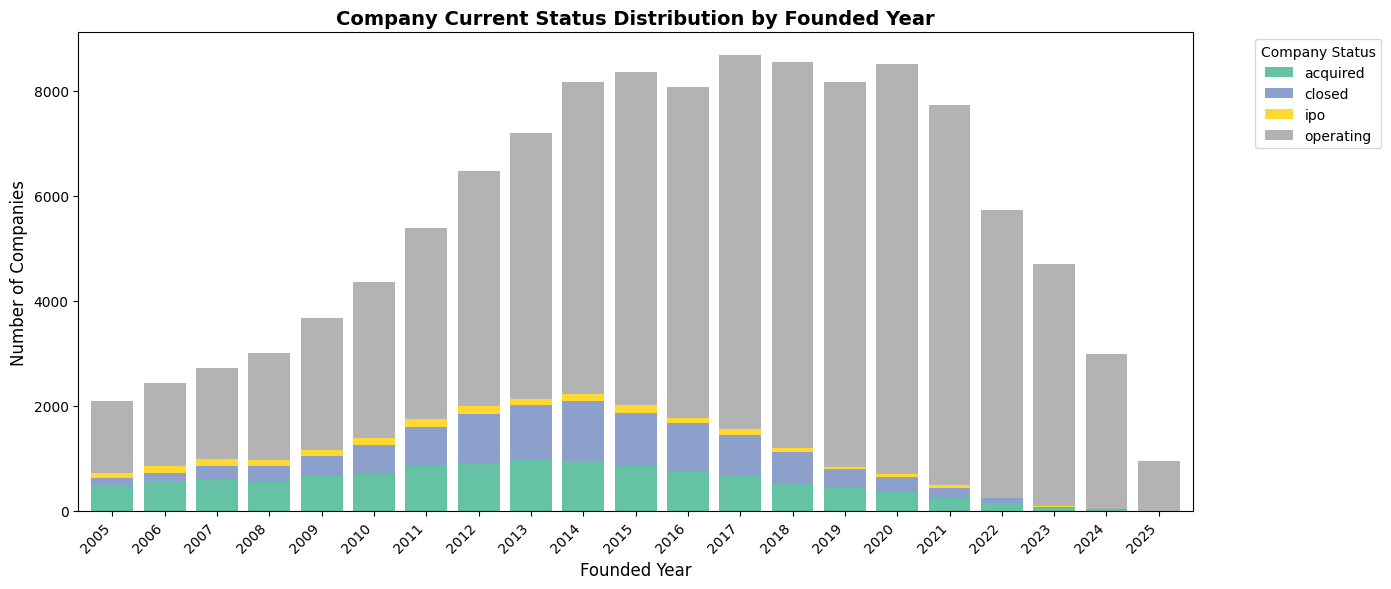

Chart saved successfully


In [43]:
# Visualization 1: Stacked Bar Chart - Company Status by Founded Year
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique companies with their status and founded year
company_status = df_org_fund.drop_duplicates(subset=['uuid'])[['founded_year', 'status']].copy()
status_counts = company_status.groupby(['founded_year', 'status']).size().unstack(fill_value=0)

status_counts.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', width=0.8)

ax.set_title('Company Current Status Distribution by Founded Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Founded Year', fontsize=12)
ax.set_ylabel('Number of Companies', fontsize=12)
ax.legend(title='Company Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Chart saved successfully")

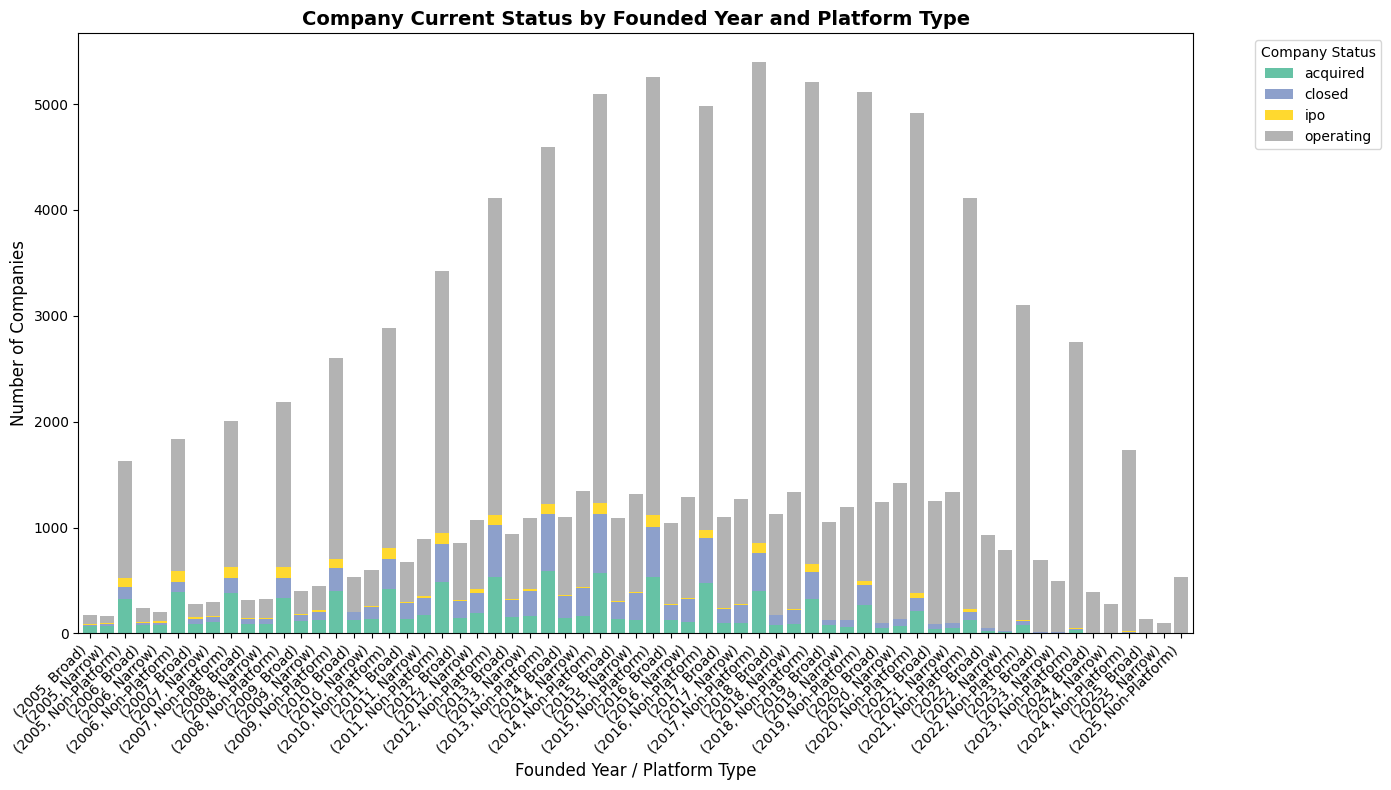

Chart saved successfully


In [70]:
fig, ax = plt.subplots(figsize=(14, 8))

# unique companies with founded_year, status, and is_platform
company_status = df_org_fund.drop_duplicates(subset=['uuid'])[
    ['founded_year', 'status', 'is_platform']
].copy()

# count by year + is_platform + status
status_counts = (
    company_status
    .groupby(['founded_year', 'is_platform', 'status'])
    .size()
    .unstack(fill_value=0)
)

# stacked bars per (year, is_platform), then reshape to clustered bars per year
status_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='Set2',
    width=0.8
)

ax.set_title('Company Current Status by Founded Year and Platform Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Founded Year / Platform Type', fontsize=12)
ax.set_ylabel('Number of Companies', fontsize=12)
ax.legend(title='Company Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Chart saved successfully")



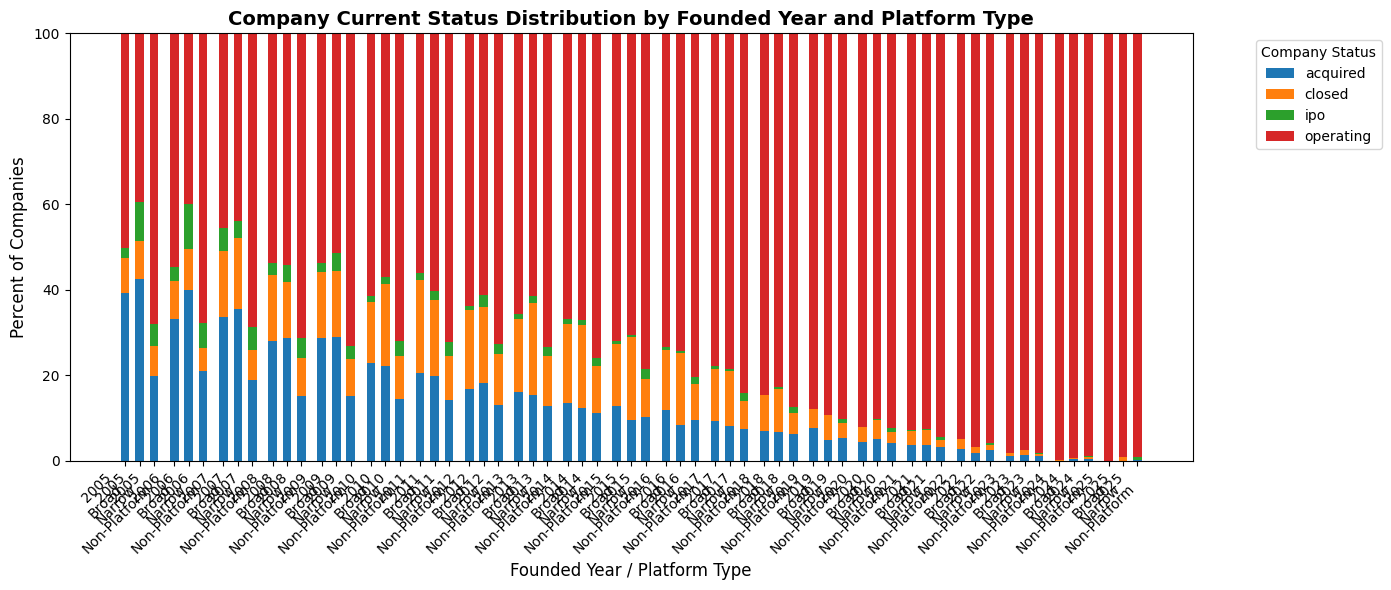

In [74]:
# Visualization: Stacked Bar Chart (percent) - Company Status by Founded Year and Platform Type
fig, ax = plt.subplots(figsize=(14, 6))

# Unique companies with founded year, status, and platform type
company_status = df_org_fund.drop_duplicates(subset=['uuid'])[
    ['founded_year', 'status', 'is_platform']
].copy()

# Count by year + platform + status
status_counts = (
    company_status
    .groupby(['founded_year', 'is_platform', 'status'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages within each (year, platform) group
status_perc = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

# Prepare positions with gaps between years and smaller gaps between platforms
years = status_perc.index.get_level_values('founded_year').unique()
platforms = status_perc.index.get_level_values('is_platform').unique()
n_platforms = len(platforms)

bar_width = 0.3
platform_gap = 0.2   # small gap between platform types
year_gap = 0.4     # larger gap between years

x_positions = []
x_labels = []

group_width = n_platforms * bar_width + (n_platforms - 1) * platform_gap

for i, year in enumerate(years):
    start = i * (group_width + year_gap)
    for j, platform in enumerate(platforms):
        x_positions.append(start + j * (bar_width + platform_gap))
        x_labels.append(f"{year}\n{platform}")

# Plot stacked bars manually
bottom = np.zeros(len(x_positions))
for status in status_perc.columns:
    vals = []
    for year in years:
        for platform in platforms:
            vals.append(status_perc.loc[(year, platform), status] if (year, platform) in status_perc.index else 0)
    ax.bar(x_positions, vals, bar_width, bottom=bottom, label=status)
    bottom += np.array(vals)

ax.set_title('Company Current Status Distribution by Founded Year and Platform Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Founded Year / Platform Type', fontsize=12)
ax.set_ylabel('Percent of Companies', fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.legend(title='Company Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



In [79]:
# Group 2: Funding Stages Distribution by Founded Year
print("\\n" + "=" * 80)
print("FUNDING STAGES DISTRIBUTION BY FOUNDED YEAR")
print("=" * 80)

# Get the earliest funding stage for each company (first funding round)
earliest_stage = df_org_fund.sort_values('FR_announced_on').drop_duplicates(subset=['uuid'], keep='first')[['uuid', 'founded_year', 'funding_stage']]

stage_by_year = earliest_stage.groupby(['founded_year', 'funding_stage']).size().unstack(fill_value=0)
stage_by_year

\n================================================================================
FUNDING STAGES DISTRIBUTION BY FOUNDED YEAR


funding_stage,Convertible Note,Other,Post-IPO,Seed,Series A,Series B,Series C,Series D,Series E,Series F+
founded_year,,,,,,,,,,
2005,9,808,16,349,441,52,10,1,1,402
2006,12,915,25,456,468,42,10,3,3,494
2007,21,982,19,622,475,31,9,2,0,563
2008,32,1153,16,784,410,24,5,3,0,583
2009,39,1343,14,1183,386,25,8,3,0,671
2010,57,1488,19,1666,411,26,5,2,0,677
2011,104,1757,25,2372,451,36,3,1,0,648
2012,137,2058,14,3069,441,26,7,0,0,728
2013,189,2323,9,3440,385,31,6,1,0,817


In [80]:
print(f"\\nFunding stages distribution (across all companies):")
earliest_stage['funding_stage'].value_counts().sort_values(ascending=False)

\nFunding stages distribution (across all companies):


funding_stage
Seed                63201
Other               33390
Series F+           11007
Series A             7383
Convertible Note     2086
Series B              523
Post-IPO              241
Series C              102
Series D               29
Series E                4
Name: count, dtype: int64

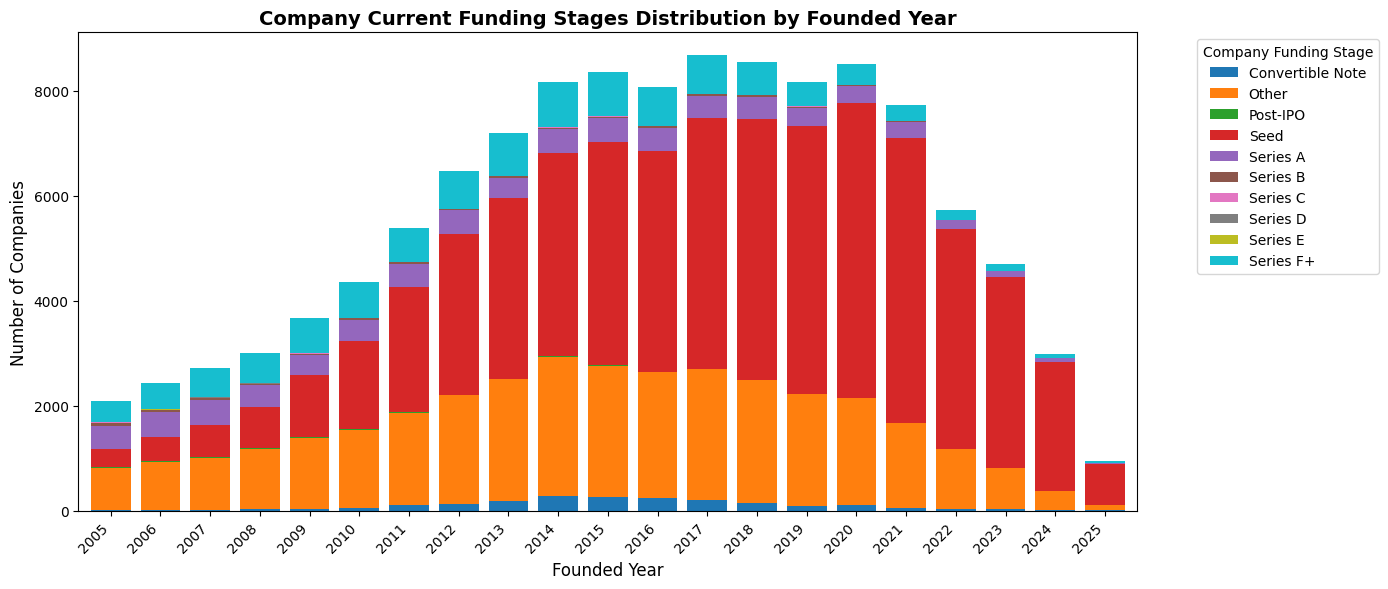

Chart saved successfully


In [83]:
# Visualization 1: Stacked Bar Chart - Company Status by Founded Year
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique companies with their status and founded year
company_status = df_org_fund.drop_duplicates(subset=['uuid'])[['founded_year', 'funding_stage']].copy()
status_counts = company_status.groupby(['founded_year', 'funding_stage']).size().unstack(fill_value=0)

status_counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)

ax.set_title('Company Current Funding Stages Distribution by Founded Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Founded Year', fontsize=12)
ax.set_ylabel('Number of Companies', fontsize=12)
ax.legend(title='Company Funding Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Chart saved successfully")

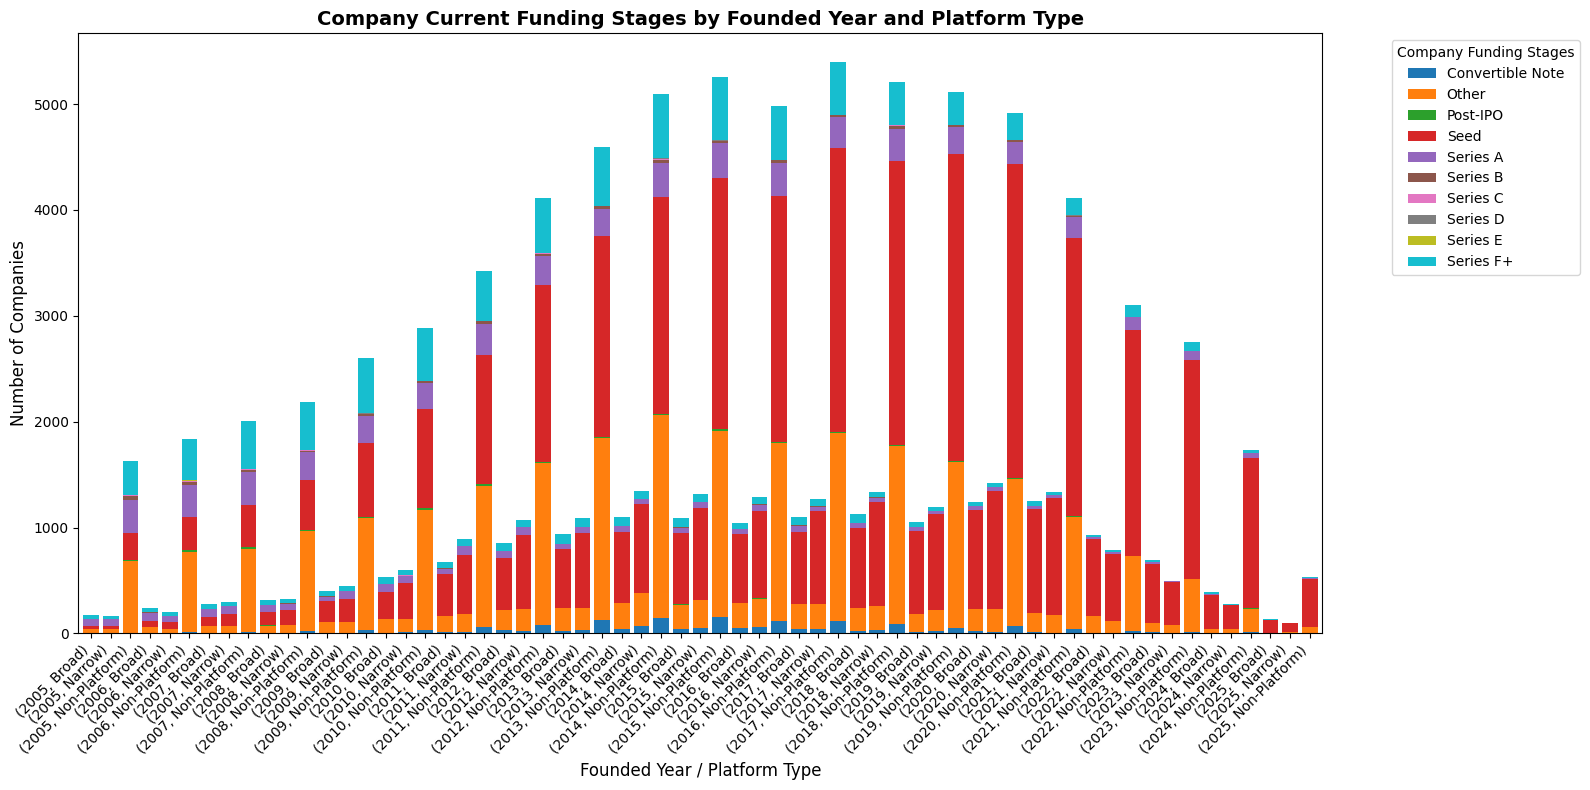

Chart saved successfully


In [86]:
fig, ax = plt.subplots(figsize=(16, 8))

# unique companies with founded_year, funding_stage, and is_platform
company_status = df_org_fund.drop_duplicates(subset=['uuid'])[
    ['founded_year', 'funding_stage', 'is_platform']
].copy()

# count by year + is_platform + funding_stage
status_counts = (
    company_status
    .groupby(['founded_year', 'is_platform', 'funding_stage'])
    .size()
    .unstack(fill_value=0)
)

# stacked bars per (year, is_platform), then reshape to clustered bars per year
status_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab10',
    width=0.8
)

ax.set_title('Company Current Funding Stages by Founded Year and Platform Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Founded Year / Platform Type', fontsize=12)
ax.set_ylabel('Number of Companies', fontsize=12)
ax.legend(title='Company Funding Stages', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Chart saved successfully")



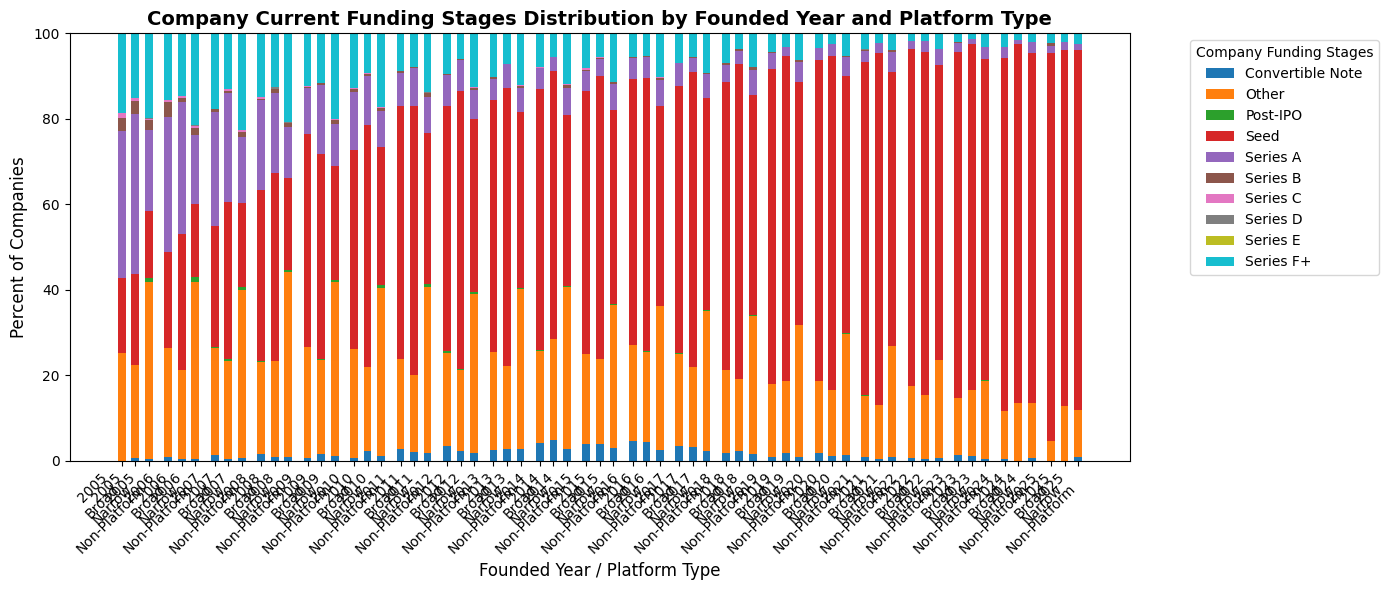

In [88]:
# Visualization: Stacked Bar Chart (percent) - Company Status by Founded Year and Platform Type
fig, ax = plt.subplots(figsize=(14, 6))

# Unique companies with founded year, funding_stage, and platform type
company_status = df_org_fund.drop_duplicates(subset=['uuid'])[
    ['founded_year', 'funding_stage', 'is_platform']
].copy()

# Count by year + platform + funding_stage
status_counts = (
    company_status
    .groupby(['founded_year', 'is_platform', 'funding_stage'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages within each (year, platform) group
status_perc = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

# Prepare positions with gaps between years and smaller gaps between platforms
years = status_perc.index.get_level_values('founded_year').unique()
platforms = status_perc.index.get_level_values('is_platform').unique()
n_platforms = len(platforms)

bar_width = 0.2
platform_gap = 0.15   # small gap between platform types
year_gap = 0.3     # larger gap between years

x_positions = []
x_labels = []

group_width = n_platforms * bar_width + (n_platforms - 1) * platform_gap

for i, year in enumerate(years):
    start = i * (group_width + year_gap)
    for j, platform in enumerate(platforms):
        x_positions.append(start + j * (bar_width + platform_gap))
        x_labels.append(f"{year}\n{platform}")

# Plot stacked bars manually
bottom = np.zeros(len(x_positions))
for status in status_perc.columns:
    vals = []
    for year in years:
        for platform in platforms:
            vals.append(status_perc.loc[(year, platform), status] if (year, platform) in status_perc.index else 0)
    ax.bar(x_positions, vals, bar_width, bottom=bottom, label=status)
    bottom += np.array(vals)

ax.set_title('Company Current Funding Stages Distribution by Founded Year and Platform Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Founded Year / Platform Type', fontsize=12)
ax.set_ylabel('Percent of Companies', fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.legend(title='Company Funding Stages', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



EXIT RATE ANALYSIS: Counts and Percentages by Founded Year and is_platform

Total exited companies analyzed: 17405
Total all companies: 117966

ABSOLUTE COUNTS: Exited Companies by Founded Year, Exit Age, and Platform Type


Non-Platform:
  Total companies: 73487, Exited: 10600, Exit rate: 14.4%
  Absolute counts:
age_bin       0-1  1-2  2-3  3-4  4-5  5-6  6-7  7-8  8-9  9-10  10-11  11-12  12-13  13-14  14-15  15-16  16-17  17-18  18-19  19-20  20+
founded_year                                                                                                                              
2005            2    3    4    9   11   10   34   25   21    31     29     28     31     30     37     24     31     15     23     22   13
2006            1    4    7    9   17   28   26   27   39    28     40     43     39     43     26     51     23     27     21     18    0
2007            0    5   10   20   24   15   28   30   40    34     31     33     55     35     62     37     24     24     16  

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_60971/4051740864.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_counts = sub_exited.groupby(['founded_year', 'age_bin']).size().unstack(fill_value=0)
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_60971/4051740864.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_counts = sub_exited.groupby(['founded_year', 'age_bin']).size().unstack(fill_value=0)
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_60971/4051740864.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

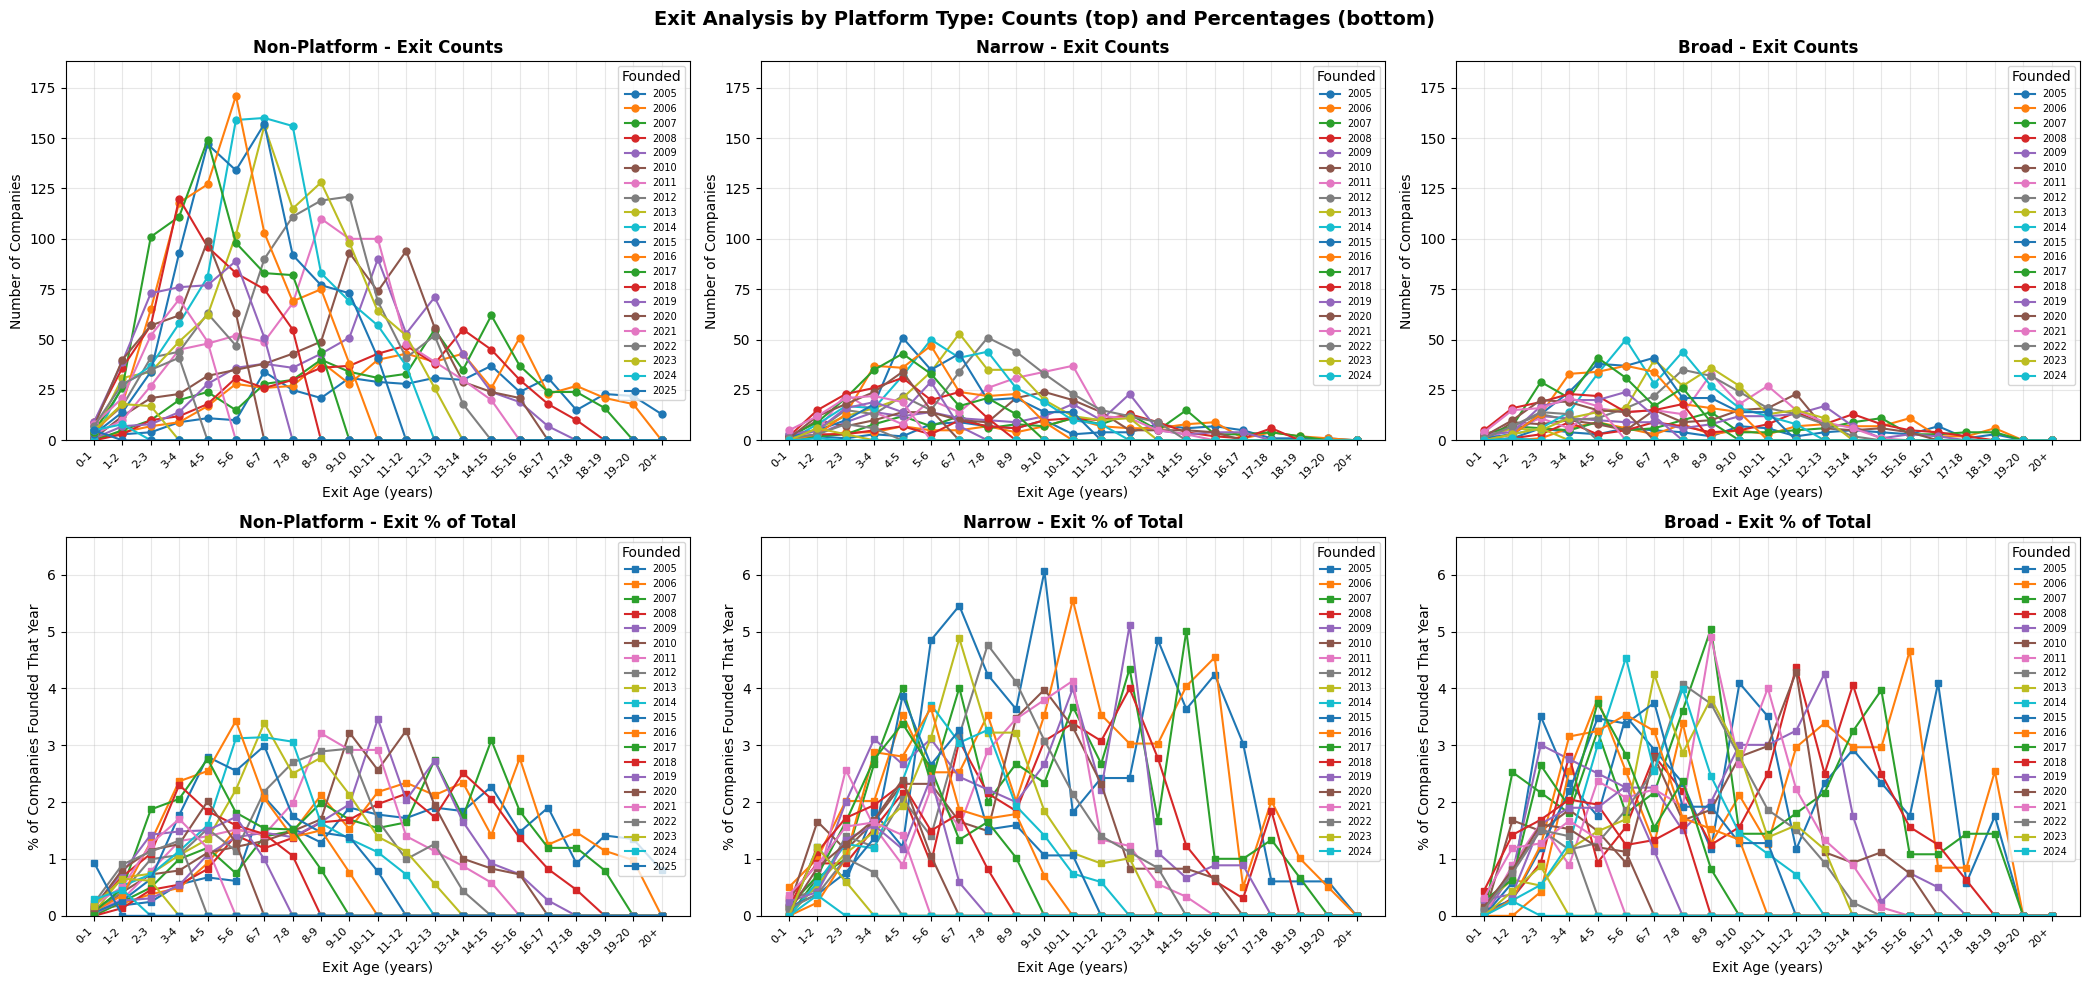


Analysis complete


In [94]:
# Exit Rate Analysis: Absolute Counts and Percentages by Founded Year and is_platform
# For each founded year and platform type, show both count and % of companies that exited at each age

# Get all companies (for denominator calculation)
all_companies = df_org_fund.drop_duplicates(subset=['uuid']).copy()
all_companies = all_companies[['uuid', 'founded_year', 'is_platform']].copy()

# Filter to exited companies only (those with company_age)
exited_companies = df_org_fund.drop_duplicates(subset=['uuid']).copy()
exited_companies = exited_companies[exited_companies['company_age'].notna()].copy()

print("="*80)
print("EXIT RATE ANALYSIS: Counts and Percentages by Founded Year and is_platform")
print("="*80)
print(f"\nTotal exited companies analyzed: {len(exited_companies)}")
print(f"Total all companies: {len(all_companies)}\n")

# Create age bins for company_age
bins = list(range(0, 21)) + [np.inf]
labels = [f'{i}-{i+1}' for i in range(20)] + ['20+']
exited_companies['age_bin'] = pd.cut(exited_companies['company_age'], bins=bins, labels=labels, right=False)

# Define platform order
platforms = ['Non-Platform', 'Narrow', 'Broad']

# Create pivot tables for each platform: founded_year vs age_bin
print("ABSOLUTE COUNTS: Exited Companies by Founded Year, Exit Age, and Platform Type\n")

for plat in platforms:
    sub_all = all_companies[all_companies['is_platform'] == plat]
    sub_exited = exited_companies[exited_companies['is_platform'] == plat]
    
    pivot_counts = sub_exited.groupby(['founded_year', 'age_bin']).size().unstack(fill_value=0)
    total_by_year = sub_all.groupby('founded_year').size()
    
    # Calculate percentages
    pivot_pct = pivot_counts.div(total_by_year, axis=0) * 100
    
    print(f"\n{plat}:")
    print(f"  Total companies: {len(sub_all)}, Exited: {len(sub_exited)}, Exit rate: {len(sub_exited)/len(sub_all)*100:.1f}%")
    print(f"  Absolute counts:")
    print(pivot_counts.to_string())
    print(f"\n  Percentage of total companies (by founding year):")
    print(pivot_pct.round(1).to_string())

# Visualization: Line plots showing counts and percentages over age buckets for each platform
# First pass: collect all pivots to determine y-axis ranges
all_pivots_counts = []
all_pivots_pct = []

for plat in platforms:
    sub_all = all_companies[all_companies['is_platform'] == plat]
    sub_exited = exited_companies[exited_companies['is_platform'] == plat]
    
    pivot_counts = sub_exited.groupby(['founded_year', 'age_bin']).size().unstack(fill_value=0)
    total_by_year = sub_all.groupby('founded_year').size()
    pivot_pct = pivot_counts.div(total_by_year, axis=0) * 100
    
    all_pivots_counts.append(pivot_counts)
    all_pivots_pct.append(pivot_pct)

# Calculate global y-axis ranges
max_count = max([p.max().max() if len(p) > 0 else 0 for p in all_pivots_counts])
max_pct = max([p.max().max() if len(p) > 0 else 0 for p in all_pivots_pct])

# Create plots with shared y-axis ranges
fig, axes = plt.subplots(2, len(platforms), figsize=(7*len(platforms), 10))
if len(platforms) == 1:
    axes = axes.reshape(2, 1)

for col, plat in enumerate(platforms):
    pivot_counts = all_pivots_counts[col]
    pivot_pct = all_pivots_pct[col]
    
    # Top row: absolute counts
    ax = axes[0, col]
    for fy in pivot_counts.index:
        if pivot_counts.loc[fy].sum() > 0:
            ax.plot(range(len(pivot_counts.columns)), pivot_counts.loc[fy].values, 
                   marker='o', label=f'{int(fy)}', linewidth=1.5, markersize=5)
    
    ax.set_title(f'{plat} - Exit Counts', fontweight='bold')
    ax.set_xlabel('Exit Age (years)')
    ax.set_ylabel('Number of Companies')
    ax.set_xticks(range(len(pivot_counts.columns)))
    ax.set_xticklabels(pivot_counts.columns, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, max_count * 1.1)  # Add 10% padding
    ax.legend(title='Founded', fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Bottom row: percentages
    ax = axes[1, col]
    for fy in pivot_pct.index:
        if pivot_pct.loc[fy].sum() > 0:
            ax.plot(range(len(pivot_pct.columns)), pivot_pct.loc[fy].values, 
                   marker='s', label=f'{int(fy)}', linewidth=1.5, markersize=5)
    
    ax.set_title(f'{plat} - Exit % of Total', fontweight='bold')
    ax.set_xlabel('Exit Age (years)')
    ax.set_ylabel('% of Companies Founded That Year')
    ax.set_xticks(range(len(pivot_pct.columns)))
    ax.set_xticklabels(pivot_pct.columns, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, max_pct * 1.1)  # Add 10% padding
    ax.legend(title='Founded', fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Exit Analysis by Platform Type: Counts (top) and Percentages (bottom)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAnalysis complete")


Founding years with exited companies: 21
Years: [np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]



/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_60971/3886388954.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exit_by_age = exited_plat.groupby('age_bin').size()
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_60971/3886388954.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exit_by_age = exited_plat.groupby('age_bin').size()
/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_60971/3886388954.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

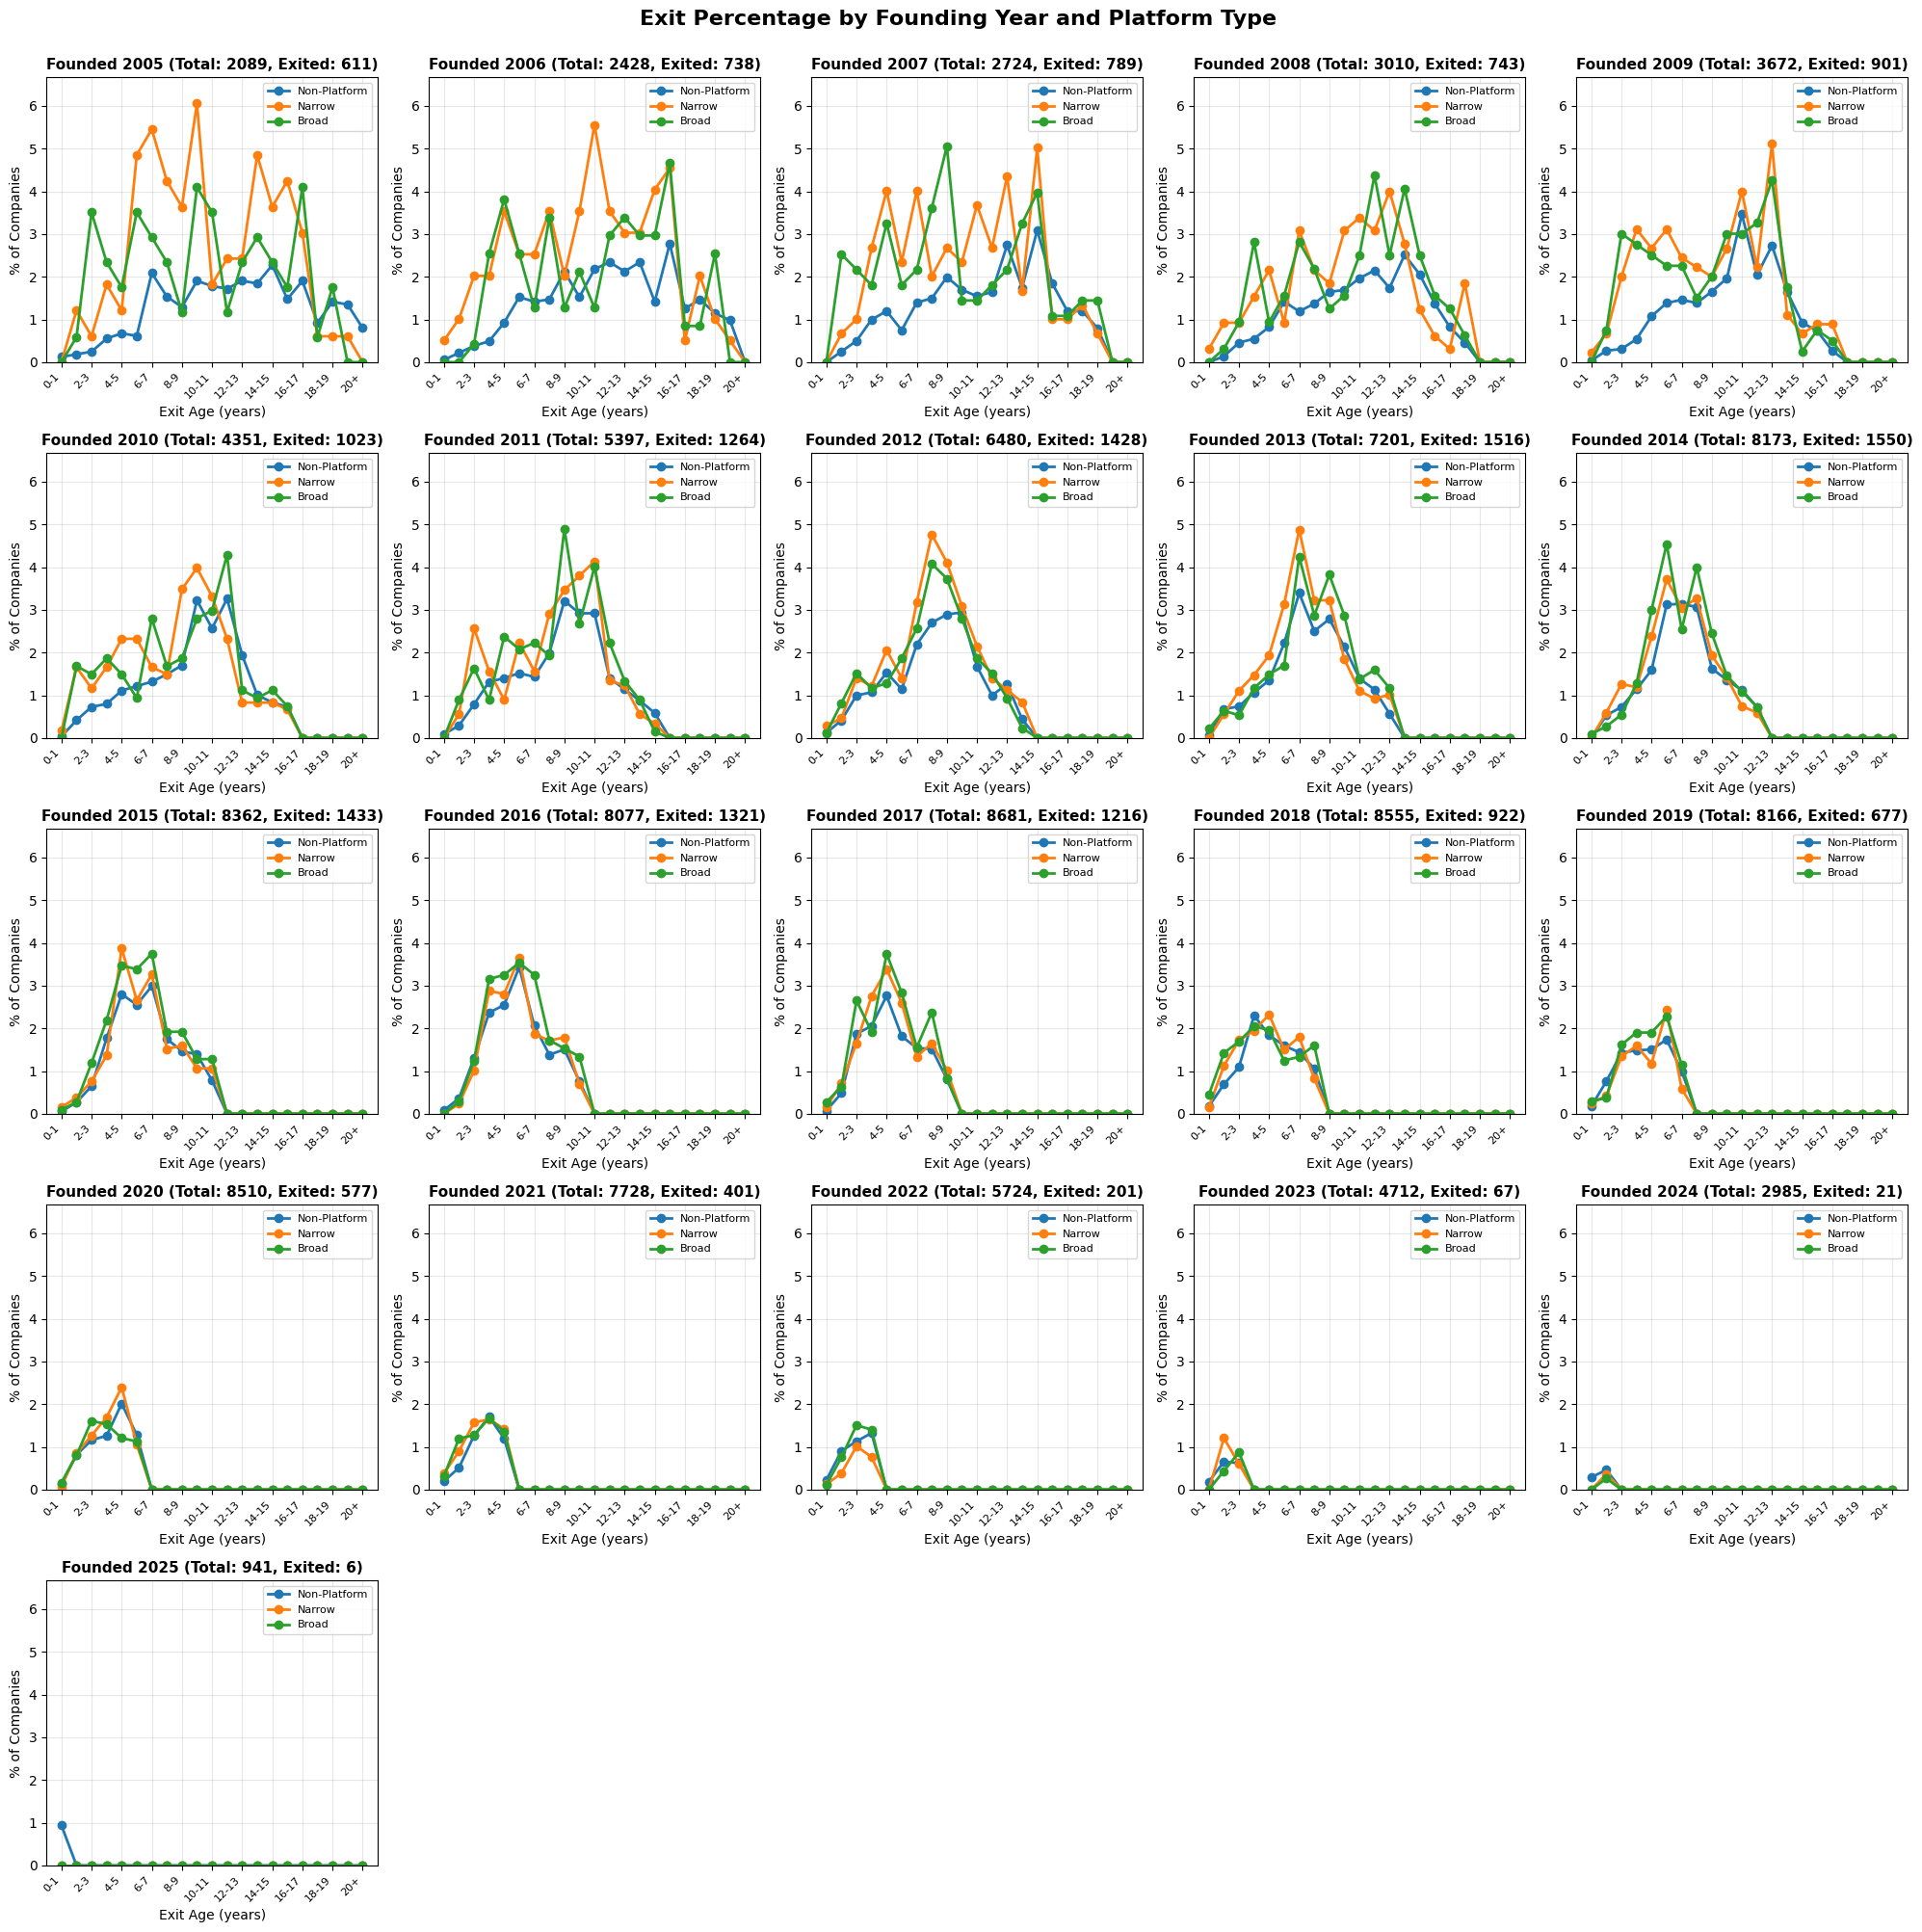

Plots by founding year complete


In [95]:
# Exit Percentage by Founding Year
# One plot for each founded year showing exit % across platform types and exit ages

# Collect all unique founding years that have exited companies
founding_years_with_exits = sorted(exited_companies['founded_year'].unique())
print(f"\nFounding years with exited companies: {len(founding_years_with_exits)}")
print(f"Years: {founding_years_with_exits}\n")

# Create subplots: one per founding year (arrange in grid)
n_years = len(founding_years_with_exits)
n_cols = 5  # 5 columns
n_rows = (n_years + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()  # Flatten to 1D for easier indexing

for idx, fy in enumerate(founding_years_with_exits):
    ax = axes[idx]
    
    # Get total companies and exited companies for this founding year
    all_fy = all_companies[all_companies['founded_year'] == fy]
    exited_fy = exited_companies[exited_companies['founded_year'] == fy]
    
    # For each platform type, get exit percentages by age
    for plat in platforms:
        all_plat = all_fy[all_fy['is_platform'] == plat]
        exited_plat = exited_fy[exited_fy['is_platform'] == plat]
        
        if len(all_plat) > 0:
            # Calculate exit % by age bin
            exit_by_age = exited_plat.groupby('age_bin').size()
            exit_pct_by_age = (exit_by_age / len(all_plat) * 100).reindex(labels, fill_value=0)
            
            ax.plot(range(len(labels)), exit_pct_by_age.values, 
                   marker='o', label=plat, linewidth=2, markersize=6)
    
    ax.set_title(f'Founded {int(fy)} (Total: {len(all_fy)}, Exited: {len(exited_fy)})', 
                fontweight='bold', fontsize=11)
    ax.set_xlabel('Exit Age (years)', fontsize=10)
    ax.set_ylabel('% of Companies', fontsize=10)
    ax.set_xticks(range(0, len(labels), 2))
    ax.set_xticklabels(labels[::2], rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, max_pct * 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(founding_years_with_exits), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Exit Percentage by Founding Year and Platform Type', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Plots by founding year complete")

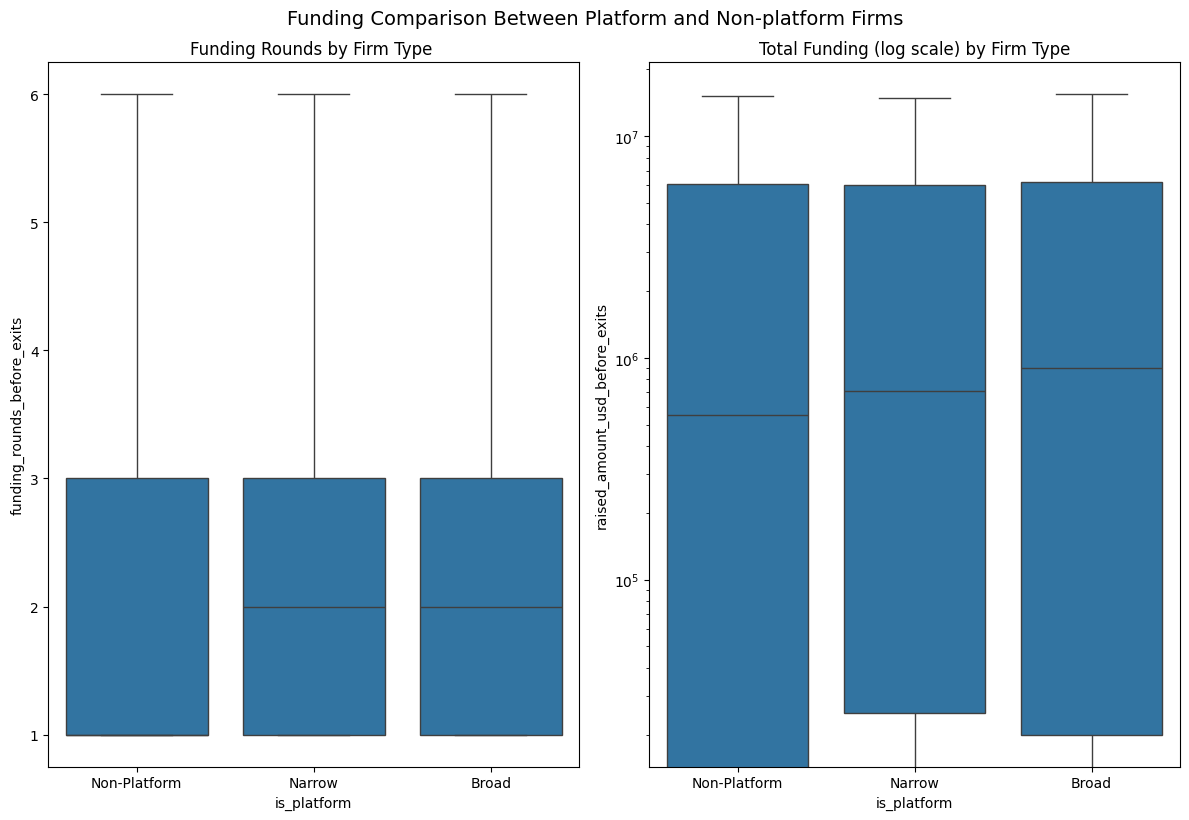

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# --- (1,1) strict - num_funding_rounds ---
sns.boxplot(
    data=df_org_grouped,
    x='is_platform',
    y='funding_rounds_before_exits',
    showfliers=False,
    ax=axes[0]
)
# axes[0].set_xticklabels(['Non-platform', 'Platform'])
axes[0].set_title('Funding Rounds by Firm Type ')

# --- (1,2) strict - total_funding_usd ---
sns.boxplot(
    data=df_org_grouped,
    x='is_platform',
    y='raised_amount_usd_before_exits',
    showfliers=False,
    ax=axes[1]
)
axes[1].set_yscale('log')
# axes[1].set_xticklabels(['Non-platform', 'Platform'])
axes[1].set_title('Total Funding (log scale) by Firm Type')


# --- Layout ---
plt.tight_layout()
plt.suptitle('Funding Comparison Between Platform and Non-platform Firms', fontsize=14, y=1.02)
plt.show()

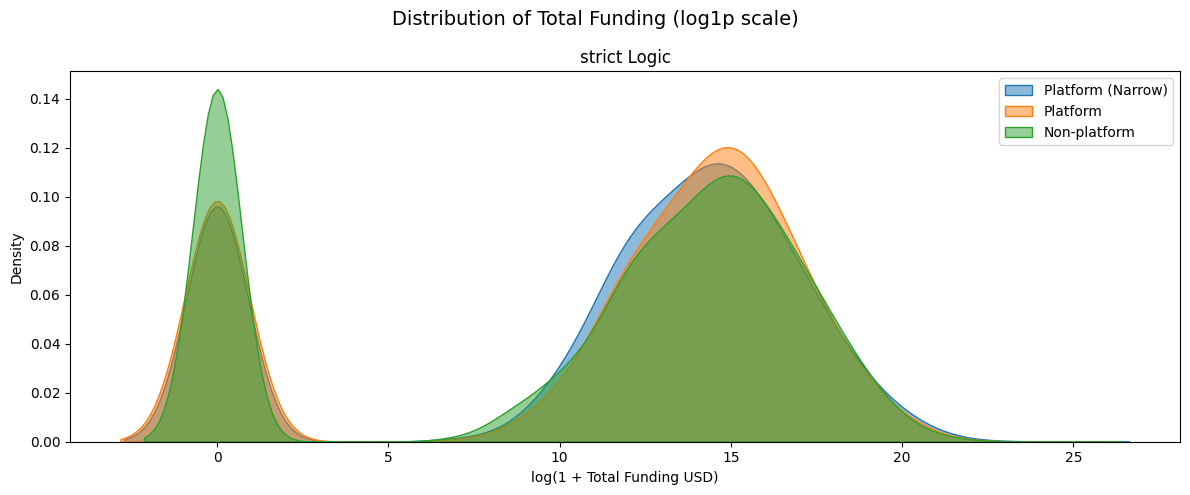

In [54]:


fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharey=True)

# --- strict ---
sns.kdeplot(np.log1p(platform_narrow['raised_amount_usd_before_exits']),
            label='Platform (Narrow)', fill=True, alpha=0.5, ax=axes)
sns.kdeplot(np.log1p(platform_broad['raised_amount_usd_before_exits']),
            label='Platform', fill=True, alpha=0.5, ax=axes)
sns.kdeplot(np.log1p(nonplatform['raised_amount_usd_before_exits']),
            label='Non-platform', fill=True, alpha=0.5, ax=axes)
axes.set_title('strict Logic')
axes.set_xlabel('log(1 + Total Funding USD)')
axes.set_ylabel('Density')
axes.legend()


plt.suptitle('Distribution of Total Funding (log1p scale)', fontsize=14)
plt.tight_layout()
plt.show()

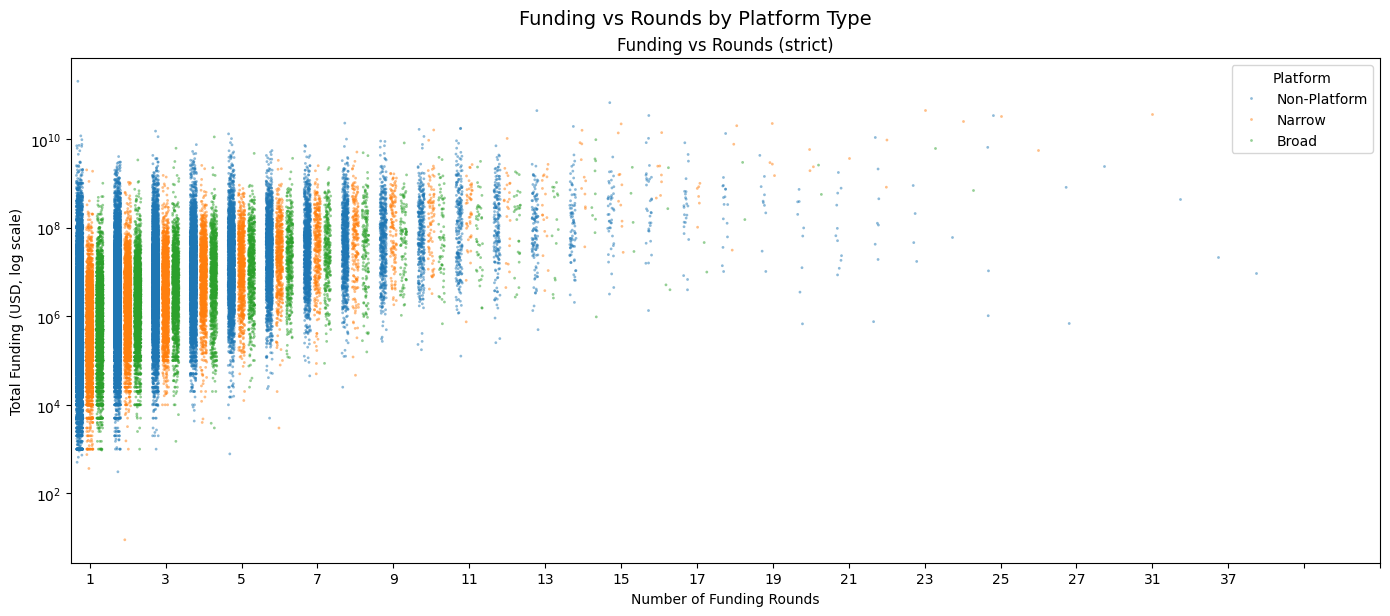

In [55]:
# Ensure integer rounds
df_org_grouped['funding_rounds_before_exits'] = df_org_grouped['funding_rounds_before_exits'].astype(int)

fig, axes = plt.subplots(1, 1, figsize=(14, 6), sharey=True)

# --- (1) strict ---
sns.stripplot(
    data=df_org_grouped,
    x='funding_rounds_before_exits',
    y='raised_amount_usd_before_exits',
    hue='is_platform',
    dodge=True,
    jitter=0.25,
    alpha=0.5,
    size=2,
    ax=axes
)
axes.set_yscale('log')
axes.set_xticks(range(0, 36, 2))
axes.set_xlabel('Number of Funding Rounds')
axes.set_ylabel('Total Funding (USD, log scale)')
axes.set_title('Funding vs Rounds (strict)')
axes.legend(title='Platform')


plt.tight_layout()
plt.suptitle('Funding vs Rounds by Platform Type', fontsize=14, y=1.02)
plt.show()

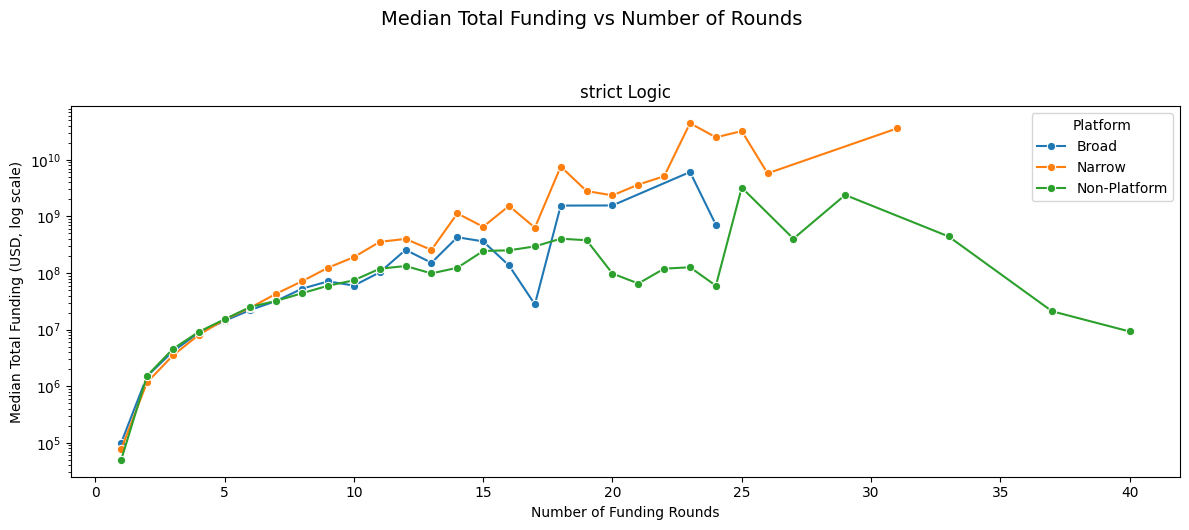

In [56]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharey=True)

# strict
avg_funding_strict = (
    df_org_grouped
    .groupby(['funding_rounds_before_exits', 'is_platform'])['raised_amount_usd_before_exits']
    .median()
    .reset_index()
)

sns.lineplot(
    data=avg_funding_strict,
    x='funding_rounds_before_exits',
    y='raised_amount_usd_before_exits',
    hue='is_platform',
    marker='o',
    ax=axes
)
axes.set_yscale('log')
axes.set_title('strict Logic')
axes.set_xlabel('Number of Funding Rounds')
axes.set_ylabel('Median Total Funding (USD, log scale)')
axes.legend(title='Platform')


plt.suptitle('Median Total Funding vs Number of Rounds ', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Descriptives
- build a panel of firms at the quarterly level that keeps track of the number of funding rounds the firm has received, the amount of funding, exits (“status” of firm) etc. 
- distinguish non-platform businesses between:   
    -“Digital” companies (software)   
    -“Non-digital” companies: robotics, industrials, hardware, consumer staples, biotech, pharmaceuticals – anything physical   
    -(So, there will be two “control groups”. Don’t worry if this distinction is very imperfect – even something approximate will be fine.)

- Startups that are private but have not raised a funding round (or recorded any other event) in 5 years can be coded as “inactive”

### 1. build a panel of firms at the quarterly level that keeps track of the number of funding rounds the firm has received, the amount of funding, exits (“status” of firm) etc. 

In [57]:
df_quarterly = df_org_fund[['uuid', 'name', 'type','created_at', 'num_funding_rounds', 'total_funding_usd', 'founded_on', 'last_funding_on','num_exits', 'FR_name', 'FR_investment_type', 'FR_announced_on', 'FR_raised_amount_usd', 'is_vc_funded', 'is_platform']].copy()
# Convert relevant dates to datetime if not already
df_quarterly['FR_announced_on'] = pd.to_datetime(df_quarterly['FR_announced_on'])

# Create quarter column using FR_announced_on
df_quarterly['quarter'] = df_quarterly['FR_announced_on'].dt.to_period('Q')

In [58]:
# Group by uuid and quarter to calculate funding metrics
quarterly_funding = df_quarterly.groupby(['uuid', 'quarter']).agg({
    'name': 'first',
    'type': 'first',
    'created_at': 'first',
    'num_funding_rounds': 'count',
    'total_funding_usd': 'first',
    'founded_on': 'first',
    'last_funding_on': 'first',
    'FR_name': lambda x: list(x),  # collect names as list
    'FR_investment_type': lambda x: list(x),  # collect names as list
    'FR_raised_amount_usd': 'sum',
    'num_exits': lambda x: x.fillna(0).sum(),  # sum exits, treating NaN as 0
    'FR_announced_on': lambda x: list(x),  # collect announced dates as list
    'is_vc_funded': 'first',
    'is_platform': 'first',

}).reset_index()

# Sort by uuid and quarter
quarterly_funding['FR_num_round'] = quarterly_funding['FR_name'].apply(len)
quarterly_funding = quarterly_funding.sort_values(['uuid', 'quarter'])

# Add cumulative metrics
quarterly_funding['cum_num_rounds'] = quarterly_funding.groupby('uuid')['FR_num_round'].cumsum()
quarterly_funding['cum_funding'] = quarterly_funding.groupby('uuid')['FR_raised_amount_usd'].cumsum()
quarterly_funding['cum_exits'] = quarterly_funding.groupby('uuid')['num_exits'].cumsum()

In [59]:
quarterly_funding[quarterly_funding['uuid']=='845a7147-8b85-093a-54f4-d0f7e891aa20']

,uuid,quarter,name,type,created_at,num_funding_rounds,total_funding_usd,founded_on,last_funding_on,FR_name,FR_investment_type,FR_raised_amount_usd,num_exits,FR_announced_on,is_vc_funded,is_platform,FR_num_round,cum_num_rounds,cum_funding,cum_exits
132713,845a7147-8b85-093a-54f4-d0f7e891aa20,2011Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Grant - Abogen],[grant],12500.0,0.0,[2011-05-09 00:00:00],0,Non-Platform,1,1,12500.0,0.0
132714,845a7147-8b85-093a-54f4-d0f7e891aa20,2011Q3,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Grant - Abogen],[grant],12500.0,0.0,[2011-07-11 00:00:00],0,Non-Platform,1,2,25000.0,0.0
132715,845a7147-8b85-093a-54f4-d0f7e891aa20,2013Q1,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Debt Financing - Abogen],[debt_financing],250000.0,0.0,[2013-02-28 00:00:00],0,Non-Platform,1,3,275000.0,0.0
132716,845a7147-8b85-093a-54f4-d0f7e891aa20,2013Q4,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],235000.0,0.0,[2013-10-01 00:00:00],1,Non-Platform,1,4,510000.0,0.0
132717,845a7147-8b85-093a-54f4-d0f7e891aa20,2014Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],50000.0,0.0,[2014-04-01 00:00:00],1,Non-Platform,1,5,560000.0,0.0
132718,845a7147-8b85-093a-54f4-d0f7e891aa20,2014Q3,Abogen,organization,2016-11-28 06:40:03,2,1405000.0,2011-01-01,2016-07-01,"[Angel Round - Abogen, Seed Round - Abogen]","[angel, seed]",225000.0,0.0,"[2014-07-01 00:00:00, 2014-07-22 00:00:00]",1,Non-Platform,2,7,785000.0,0.0
132719,845a7147-8b85-093a-54f4-d0f7e891aa20,2015Q1,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Angel Round - Abogen],[angel],30000.0,0.0,[2015-01-01 00:00:00],1,Non-Platform,1,8,815000.0,0.0
132720,845a7147-8b85-093a-54f4-d0f7e891aa20,2015Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Debt Financing - Abogen],[debt_financing],25000.0,0.0,[2015-06-30 00:00:00],0,Non-Platform,1,9,840000.0,0.0
132721,845a7147-8b85-093a-54f4-d0f7e891aa20,2016Q2,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],450000.0,0.0,[2016-06-01 00:00:00],1,Non-Platform,1,10,1290000.0,0.0
132722,845a7147-8b85-093a-54f4-d0f7e891aa20,2016Q3,Abogen,organization,2016-11-28 06:40:03,1,1405000.0,2011-01-01,2016-07-01,[Seed Round - Abogen],[seed],115000.0,0.0,[2016-07-01 00:00:00],1,Non-Platform,1,11,1405000.0,0.0


Text(0.5, 1.0, 'Quarterly Exits (M&A/IPO) by Firm Type')

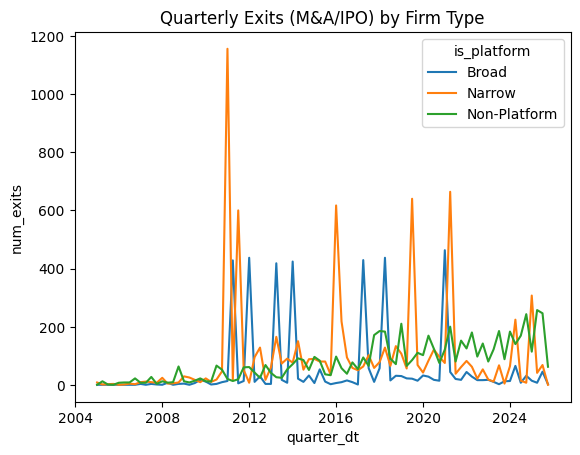

In [60]:
quarterly_funding['quarter_dt'] = pd.PeriodIndex(quarterly_funding['quarter'], freq='Q').to_timestamp()
exit_trend = quarterly_funding.groupby(['quarter_dt','is_platform'])['num_exits'].sum().reset_index()
sns.lineplot(data=exit_trend, x='quarter_dt', y='num_exits', hue='is_platform')
plt.title('Quarterly Exits (M&A/IPO) by Firm Type')

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_82213/3532257812.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


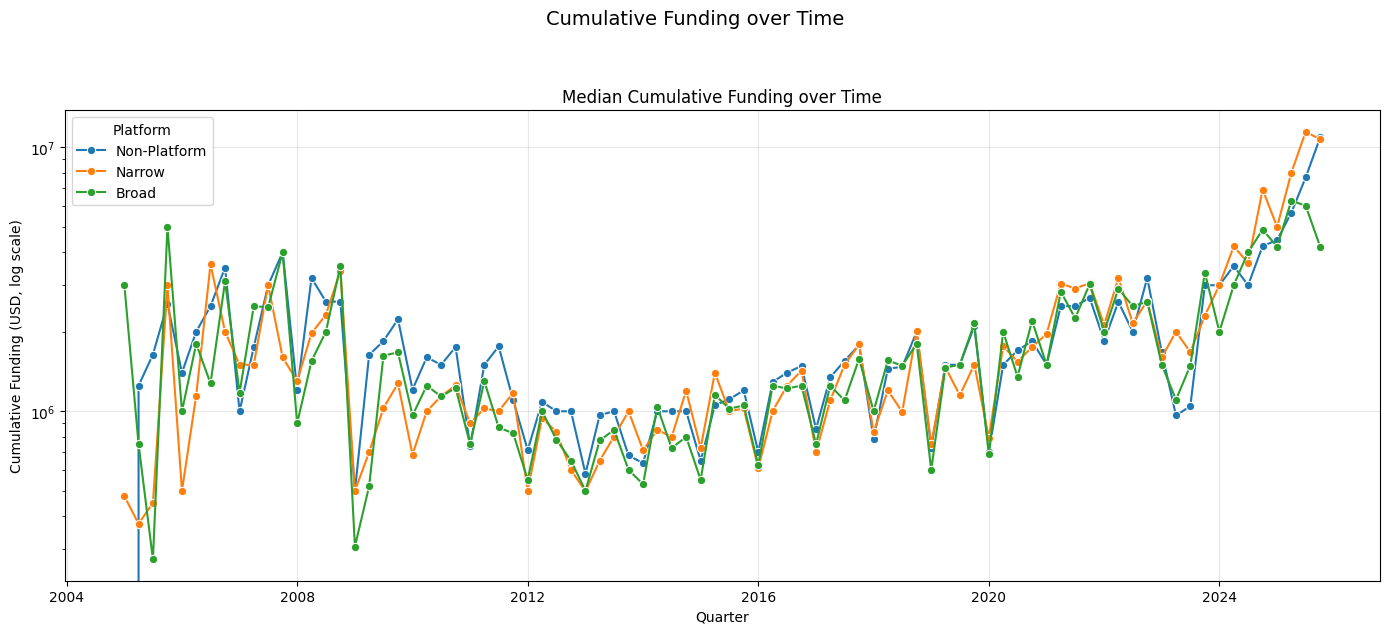

In [61]:

fig, axes = plt.subplots(1, 1, figsize=(14, 6), sharey=True)

# ---------------- strict ----------------
sns.lineplot(
    data=quarterly_funding, 
    x='quarter_dt', 
    y='cum_funding', 
    hue='is_platform',
    estimator='median',
    ci=None,
    ax=axes,
    marker='o'
)
axes.set_title('Median Cumulative Funding over Time')
axes.set_xlabel('Quarter')
axes.set_ylabel('Cumulative Funding (USD, log scale)')
axes.set_yscale('log')
axes.legend(title='Platform')
axes.grid(alpha=0.3)
# Adjust layout
plt.suptitle('Cumulative Funding over Time', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_82213/4190912793.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


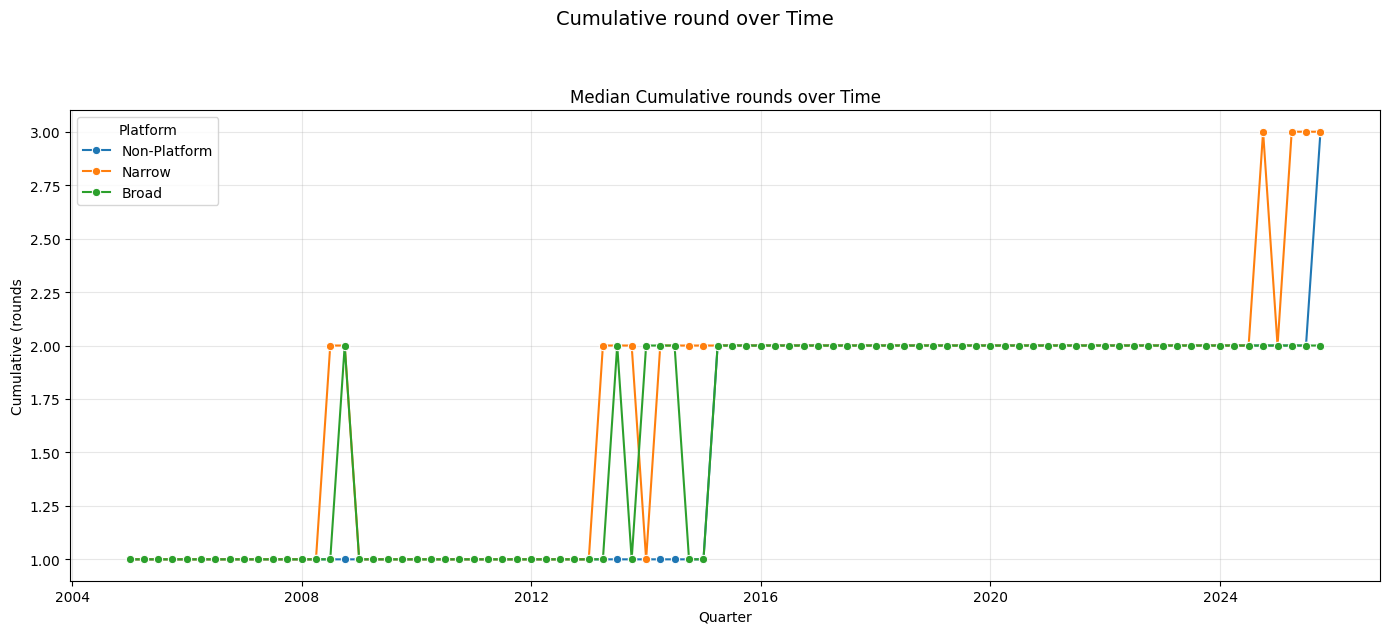

In [62]:

quarterly_funding['quarter_dt'] = pd.PeriodIndex(quarterly_funding['quarter'], freq='Q').to_timestamp()
# Create subplots
fig, axes = plt.subplots(1, 1, figsize=(14, 6), sharey=True)

# ---------------- strict ----------------
sns.lineplot(
    data=quarterly_funding, 
    x='quarter_dt', 
    y='cum_num_rounds', 
    hue='is_platform',
    estimator='median',
    ci=None,
    ax=axes,
    marker='o'
)
axes.set_title('Median Cumulative rounds over Time')
axes.set_xlabel('Quarter')
axes.set_ylabel('Cumulative (rounds')
axes.legend(title='Platform')
axes.grid(alpha=0.3)
# Adjust layout
plt.suptitle('Cumulative round over Time', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Conclusion: 


## Interesting descriptives:
### Age
1. Conditional on startup age (for example, for all startups of age 5 years), what is the average number of funding rounds for platform vs. non-platform businesses? (Start with “VC only”; later could separately study all funding rounds) Total amount of funding for platform vs. non-platform businesses?
2. “Round cadence”: in a given company age, (number of rounds since start) / (years since first funding round)  Separately for platform vs. control groups
3. Conditional on startup age (for example, all startups of age 5 years), what is the rate of 
   - Being closed / inactive,
   - Being acquired,
   - Having gone public?

In [63]:
# for item 3 above 
df_company_age_status= df_org_grouped[['uuid', 'name', 'company_age','status', 'is_inactive', 'is_vc_funded', 'is_platform', 'is_digital_nonplatform']].copy()
df_company_age_status['new_status'] = np.where(
    (df_company_age_status['is_inactive']==1 | df_company_age_status['status'].isin(['closed'])),
    'close/inactive',
    df_company_age_status['status']
)

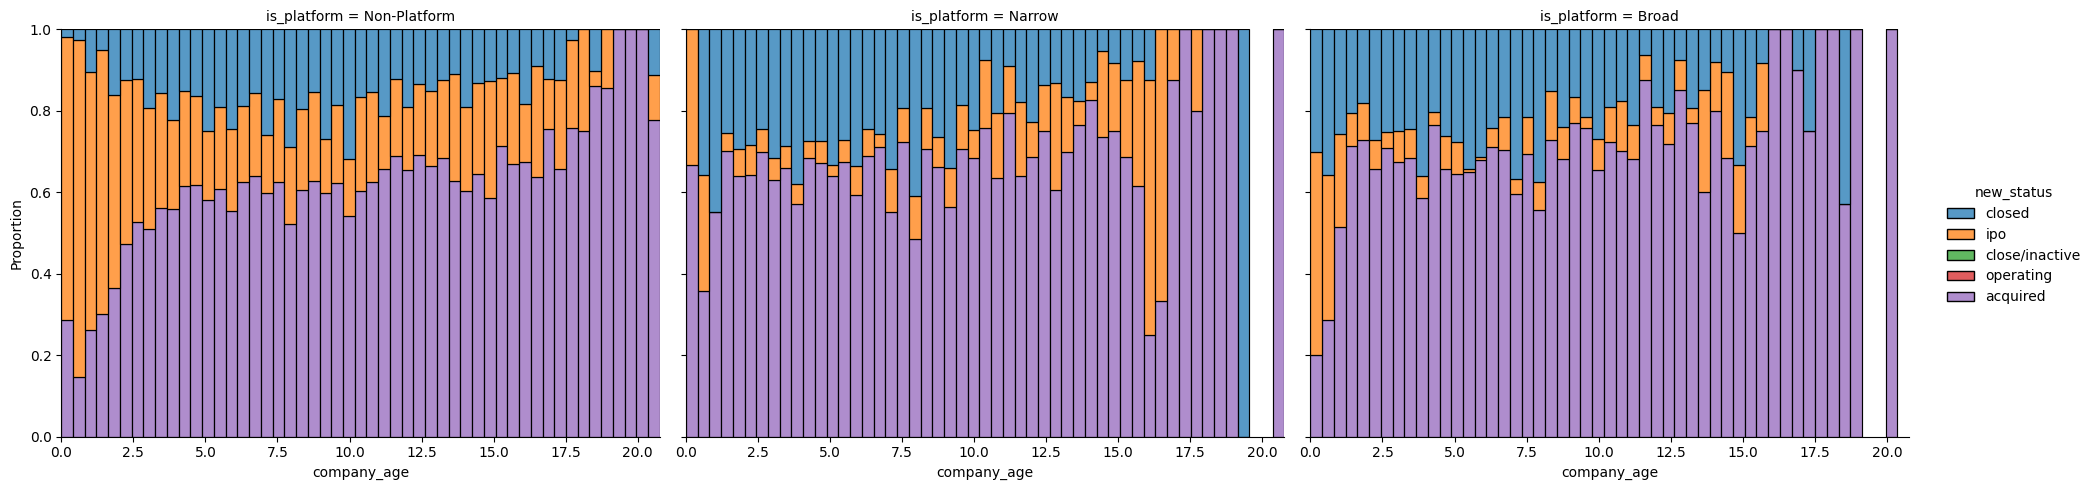

In [64]:
sns.displot(
    data=df_company_age_status,
    x='company_age',
    hue='new_status',
    col='is_platform',
    kind='hist',
    stat='proportion',
    multiple='fill',
    height=5,
    aspect=1.3
)

In [65]:
status_counts = (
    df_company_age_status
    .groupby(['company_age', 'is_platform', 'new_status'])
    .size()
    .reset_index(name='count')
)
status_counts['percent'] = (
    status_counts.groupby(['company_age', 'is_platform'])['count']
    .transform(lambda x: x / x.sum())
)

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_82213/3436020312.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5430,) and arg 1 with shape (2117,).

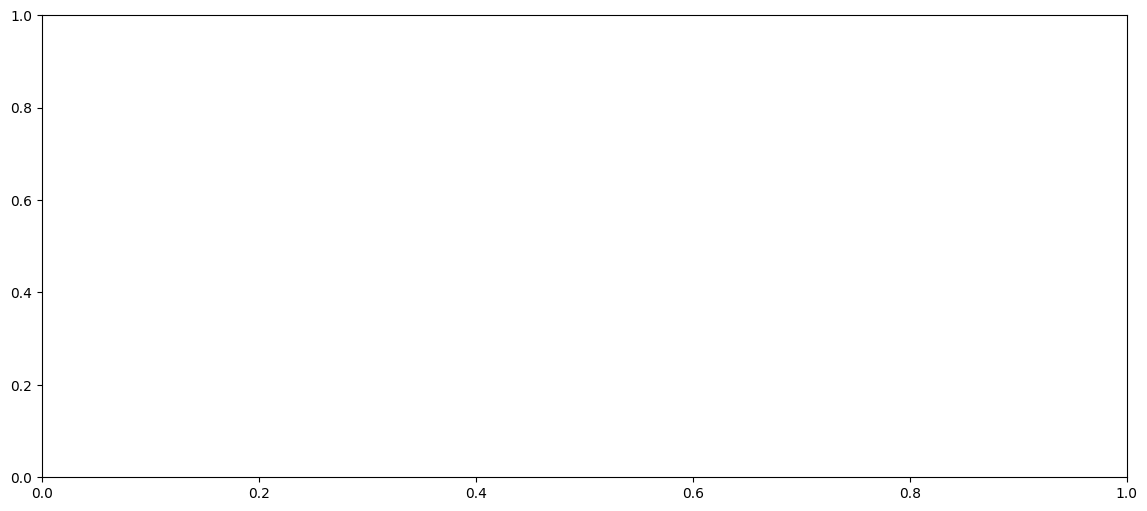

In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = status_counts.copy()

pivot = df.pivot_table(
    index=["company_age", "is_platform"],
    columns="new_status",
    values="percent",
    fill_value=0,
).reset_index()

statuses = pivot.columns[2:] 

ages = sorted(pivot["company_age"].unique())
platforms = ['Narrow', 'Broad', 'Non-Platform']
bar_width = 0.4


cmap = plt.cm.get_cmap("tab10")
colors = {status: cmap(i) for i, status in enumerate(statuses)}

fig, ax = plt.subplots(figsize=(14, 6))
x_base = np.arange(len(ages))

for p_idx, p in enumerate(platforms):

    subset = pivot[pivot["is_platform"] == p]
    x_pos = x_base + (p_idx - 0.5) * bar_width
    bottom = np.zeros(len(subset))

    for st in statuses:
        vals = subset[st].values
        ax.bar(
            x_pos, vals, bar_width,
            bottom=bottom,
            color=colors[st],         
            label=st if p_idx == 0 else None   
        )
        bottom += vals

ax.set_xticks(x_base)
ax.set_xticklabels(ages)
ax.set_xlabel("Company Age")
ax.set_ylabel("Percent")
ax.set_title("Status Distribution by Age (Platform vs Non-platform)")
ax.legend(title="Status")

plt.tight_layout()
plt.show()

In [ ]:
df_company_age = df_org_grouped[['uuid', 'name','short_description', 'created_at', 'company_age','num_funding_rounds', 'first_round_on','total_funding_usd', 'num_exits', 'is_inactive', 'is_vc_funded', 'is_platform', 'is_digital_nonplatform']].copy()
# only consider vc funded companies
df_company_age = df_company_age[df_company_age['is_vc_funded'] == 1]
today = pd.Timestamp.today()
df_company_age['years_since_first_round'] = ((today - df_company_age['first_round_on']).dt.days / 365)
df_company_age['round_cadence'] = df_company_age['num_funding_rounds']/df_company_age['years_since_first_round']

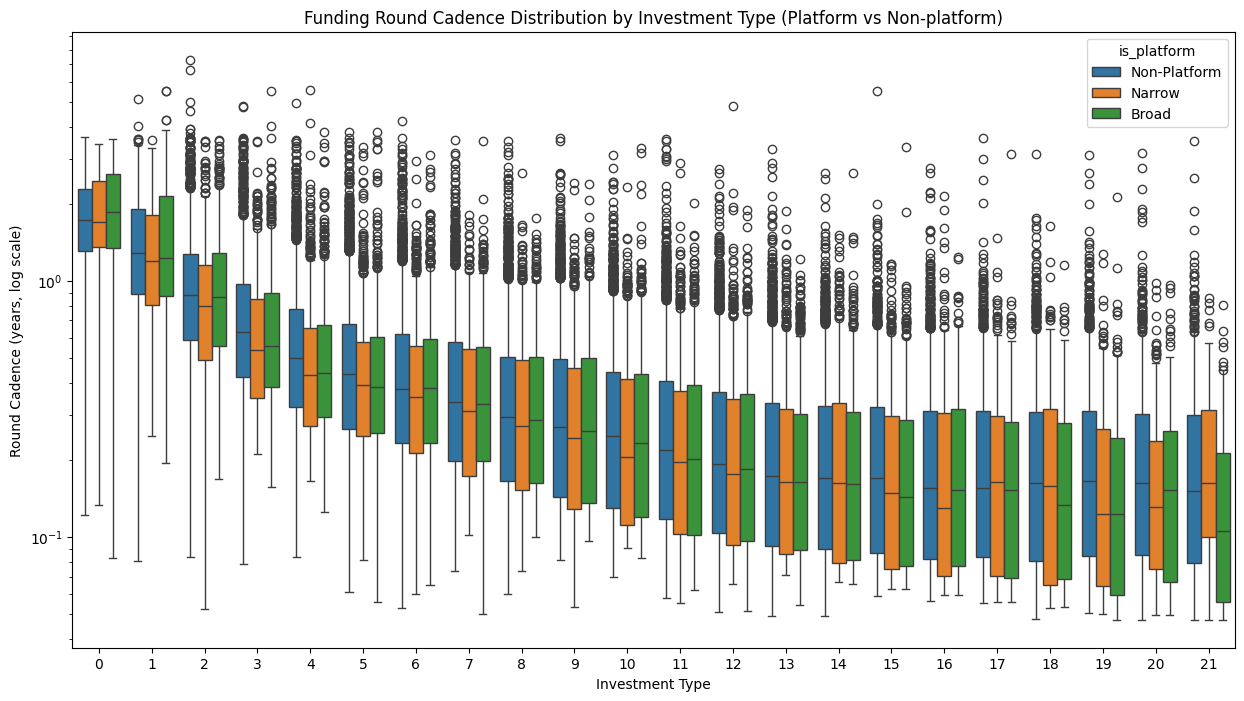

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df_company_age,
    hue='is_platform',
    y='round_cadence',
    x='company_age'
)
plt.yscale('log')
plt.title("Funding Round Cadence Distribution by Investment Type (Platform vs Non-platform)")
plt.xlabel("Investment Type")
plt.ylabel("Round Cadence (years, log scale)")
plt.show()

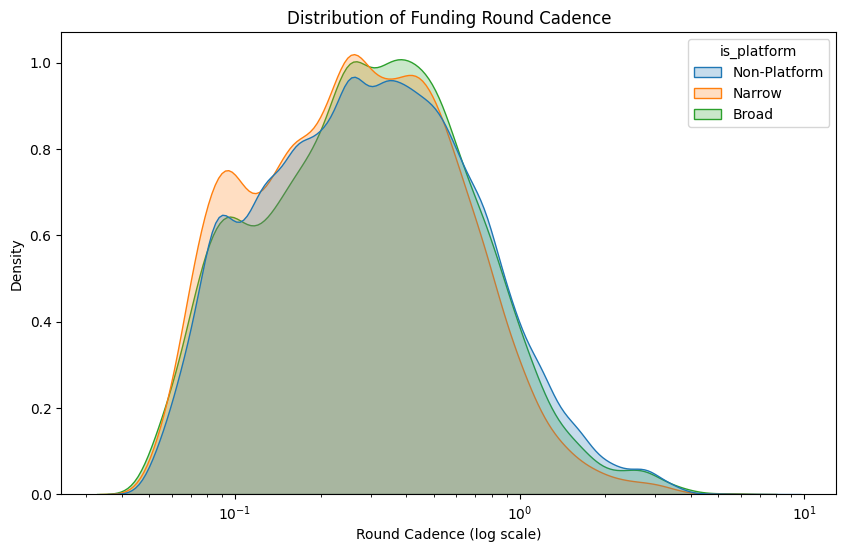

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_company_age,
    x='round_cadence',
    hue='is_platform',
    log_scale=True,
    fill=True,
    common_norm=False
)
plt.title("Distribution of Funding Round Cadence")
plt.xlabel("Round Cadence (log scale)")
plt.show()

In [ ]:
platform_col = 'is_platform'
df_age_grouped = df_company_age.groupby(['company_age', platform_col]).agg({
    'uuid': 'count',
    'num_funding_rounds': 'mean',
    'total_funding_usd': 'mean',
    'num_exits': 'mean',
}).reset_index()
df_age_grouped = df_age_grouped.fillna(0)

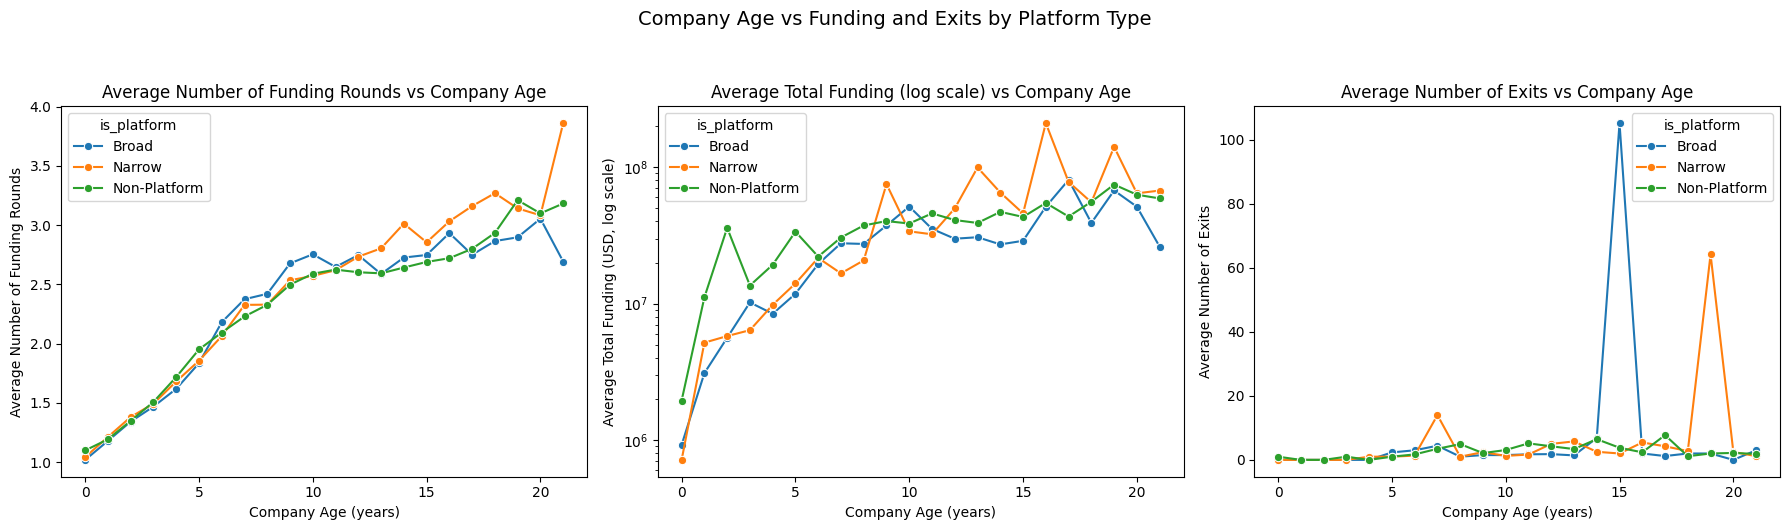

In [ ]:
# plot lines for num_funding_rounds, total_funding_usd, num_exits vs company_age
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(
    data=df_age_grouped,
    x='company_age',
    y='num_funding_rounds',
    hue=platform_col,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average Number of Funding Rounds vs Company Age')
axes[0].set_xlabel('Company Age (years)')
axes[0].set_ylabel('Average Number of Funding Rounds')
# axes[0].legend(title='Platform', labels=['Non-platform','Platform'])
sns.lineplot(
    data=df_age_grouped,
    x='company_age',
    y='total_funding_usd',
    hue=platform_col,
    marker='o',
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Average Total Funding (log scale) vs Company Age')
axes[1].set_xlabel('Company Age (years)')
axes[1].set_ylabel('Average Total Funding (USD, log scale)')
# axes[1].legend(title='Platform', labels=['Non-platform','Platform'])
sns.lineplot(
    data=df_age_grouped,
    x='company_age',
    y='num_exits',
    hue=platform_col,
    marker='o',
    ax=axes[2]
)
axes[2].set_title('Average Number of Exits vs Company Age')
axes[2].set_xlabel('Company Age (years)')
axes[2].set_ylabel('Average Number of Exits')
# axes[2].legend(title='Platform', labels=['Non-platform','Platform'])
plt.suptitle('Company Age vs Funding and Exits by Platform Type', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

- What is the average and median size of funding rounds of types series_a, series_b, series_c for platform vs. non-platform businesses?

In [ ]:
df_fund_rounds = df_org_fund[['FR_org_uuid', 'name', 'FR_investment_type', 'FR_raised_amount_usd', 'is_platform']].copy()
# keep only some founds 
keep_investment_types = ['angel', 'pre_seed', 'seed', 'series_a', 'series_b', 'series_c','series_d','series_e','series_f','series_g','series_h','series_i', 'series_j']
df_fund_rounds = df_fund_rounds[df_fund_rounds['FR_investment_type'].isin(keep_investment_types)]
df_fund_rounds['FR_investment_type'] = pd.Categorical(
    df_fund_rounds['FR_investment_type'],
    categories=keep_investment_types,
    ordered=True
)

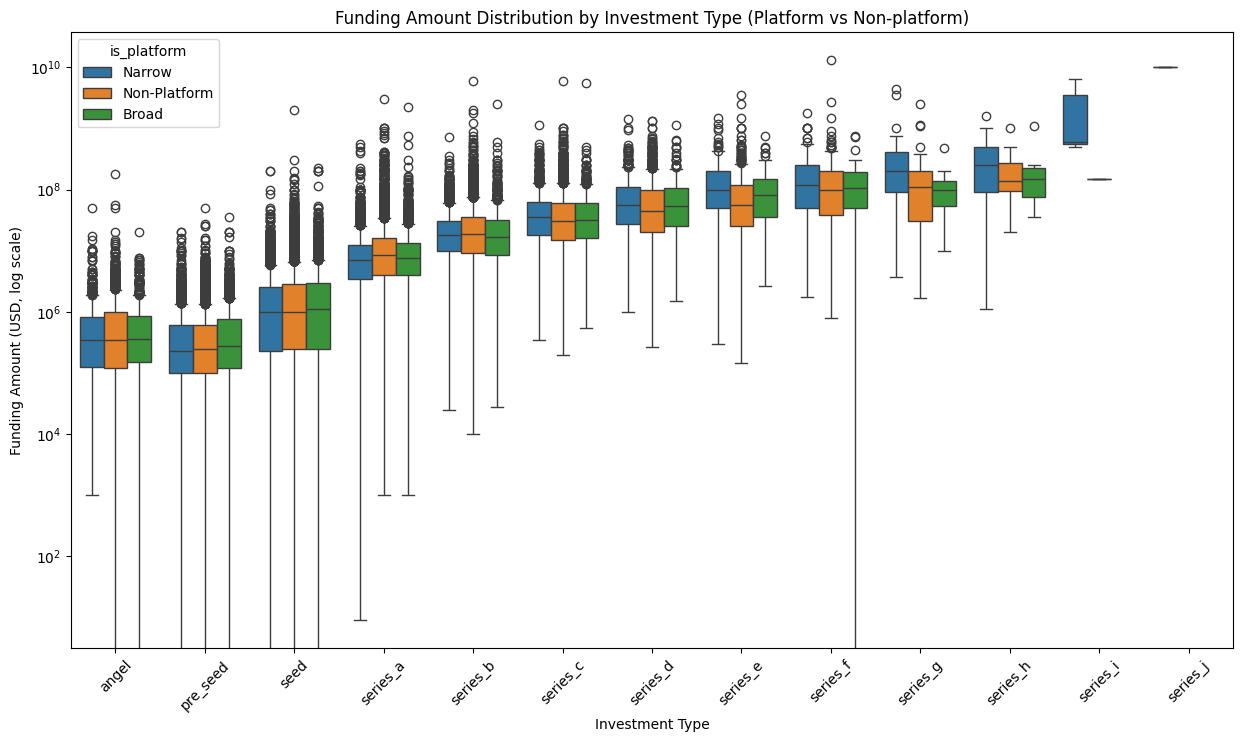

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df_fund_rounds[df_fund_rounds['FR_investment_type'].isin(keep_investment_types)],
    x='FR_investment_type',
    y='FR_raised_amount_usd',
    hue='is_platform'
)
plt.yscale('log')
plt.title("Funding Amount Distribution by Investment Type (Platform vs Non-platform)")
plt.xlabel("Investment Type")
plt.ylabel("Funding Amount (USD, log scale)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
platform_col = 'is_platform'
df_rounds_grouped = df_fund_rounds.groupby(['FR_investment_type', platform_col]).agg({
    'FR_org_uuid': 'count',
    'FR_raised_amount_usd': ['mean',lambda x: x.quantile(0.25), 'median',lambda x: x.quantile(0.75)],
}).reset_index()
df_rounds_grouped.columns = ['FR_investment_type', platform_col, 'company_count', 'raised_amount_mean', 'raised_amount_25', 'raised_amount_median', 'raised_amount_75']

/var/folders/zp/y0mkwy7d4jz3mdv2npxr4v2c0000gn/T/ipykernel_25711/3047898746.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_rounds_grouped = df_fund_rounds.groupby(['FR_investment_type', platform_col]).agg({


In [ ]:
df_rounds_grouped

,FR_investment_type,is_platform,company_count,raised_amount_mean,raised_amount_25,raised_amount_median,raised_amount_75
0,angel,Broad,1223,7.308535e+05,1.500000e+05,3.599980e+05,8.470000e+05
1,angel,Narrow,1654,7.492720e+05,1.256250e+05,3.500000e+05,8.175000e+05
2,angel,Non-Platform,3062,9.263886e+05,1.215000e+05,3.500000e+05,1.000000e+06
3,pre_seed,Broad,4787,6.618104e+05,1.200000e+05,2.760000e+05,7.500000e+05
4,pre_seed,Narrow,5661,5.501694e+05,1.000000e+05,2.305320e+05,6.000000e+05
5,pre_seed,Non-Platform,15062,5.970270e+05,1.000000e+05,2.500000e+05,6.000000e+05
6,seed,Broad,12192,2.236638e+06,2.500100e+05,1.100000e+06,3.000000e+06
7,seed,Narrow,14376,1.889516e+06,2.250000e+05,1.000000e+06,2.500000e+06
8,seed,Non-Platform,42078,2.250783e+06,2.500000e+05,1.000000e+06,2.800000e+06
9,series_a,Broad,3744,1.208071e+07,4.000000e+06,7.500000e+06,1.350000e+07


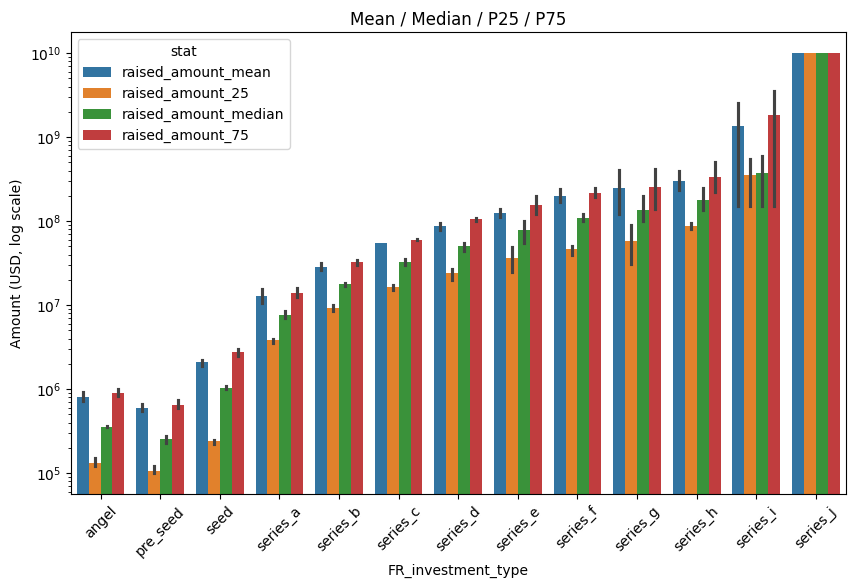

In [ ]:
quant_long = df_rounds_grouped.melt(
    id_vars=['FR_investment_type', 'is_platform'],
    value_vars=['raised_amount_mean', 'raised_amount_25', 'raised_amount_median', 'raised_amount_75'],
    var_name='stat',
    value_name='amount'
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=quant_long,
    x='FR_investment_type',
    y='amount',
    hue='stat',
)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Mean / Median / P25 / P75")
plt.ylabel("Amount (USD, log scale)")
plt.show()

Conditional on going public, what is the
- Amount of funding,
- Number of rounds,
- Years since first round for platform vs. non-platform businesses?

In [ ]:
df_ipo = df_org_grouped[['uuid', 'name','short_description', 'created_at', 'status','company_age','num_funding_rounds', 'first_round_on','total_funding_usd', 'num_exits', 'is_inactive', 'is_vc_funded', 'is_platform', 'is_digital_nonplatform']].copy()
df_ipo = df_ipo[df_ipo['status']=='ipo']
df_ipo['years_since_first_round'] = ((today - df_ipo['first_round_on']).dt.days / 365)
platform_col = 'is_platform'

In [ ]:
df_ipo.head()

,uuid,name,short_description,created_at,status,company_age,num_funding_rounds,first_round_on,total_funding_usd,num_exits,is_inactive,is_vc_funded,is_platform,is_digital_nonplatform,years_since_first_round
1,00002106-f78f-4fe7-9b14-190ec6d4aff1,Greenheart Gold,Greenheart Gold is a mining company that explores and develops minerals and gold projects.,2024-09-10 04:41:33,ipo,2,1,2024-09-25,2.673128e+07,NaN,NaN,0,Non-Platform,0,1.317808
26,000d602f-7313-49bf-95dc-0bc0106b30f5,ONGold Resources,ONGold Resources is a mining company that explores and develops gold mines.,2024-05-10 03:45:42,ipo,4,2,2024-12-10,9.025885e+06,NaN,NaN,0,Non-Platform,0,1.109589
68,00255195-c1ba-4fcc-8a05-066eedbeee26,Vanguard Mining,Vanguard Mining Corp is a mineral exploration firm focused on the discovery and development of high-value uranium prospects.,2024-08-14 11:17:06,ipo,16,2,2025-07-22,1.733465e+06,NaN,NaN,0,Non-Platform,0,0.495890
87,002e0b73-ab4e-bfd5-0d9a-e6df8fede446,BioAtla,"BioAtla develops safer, more effective drugs for cancer using a proprietary next-generation antibody discovery and evolution platform.",2015-07-22 12:25:35,ipo,19,7,2015-06-11,3.357000e+08,NaN,NaN,1,Non-Platform,0,10.616438
130,00441a55-dc2d-e4e6-6450-967db4ac6012,Four Corners Property Trust,Four Corners Property Trust is a real estate investment trust that engages primarily in management.,2016-04-09 07:43:17,ipo,11,2,2024-03-14,1.025000e+09,NaN,NaN,0,Non-Platform,1,1.852055


In [ ]:
df_ipo[platform_col].value_counts()

is_platform
Non-Platform    2719
Narrow           199
Broad            145
Name: count, dtype: int64

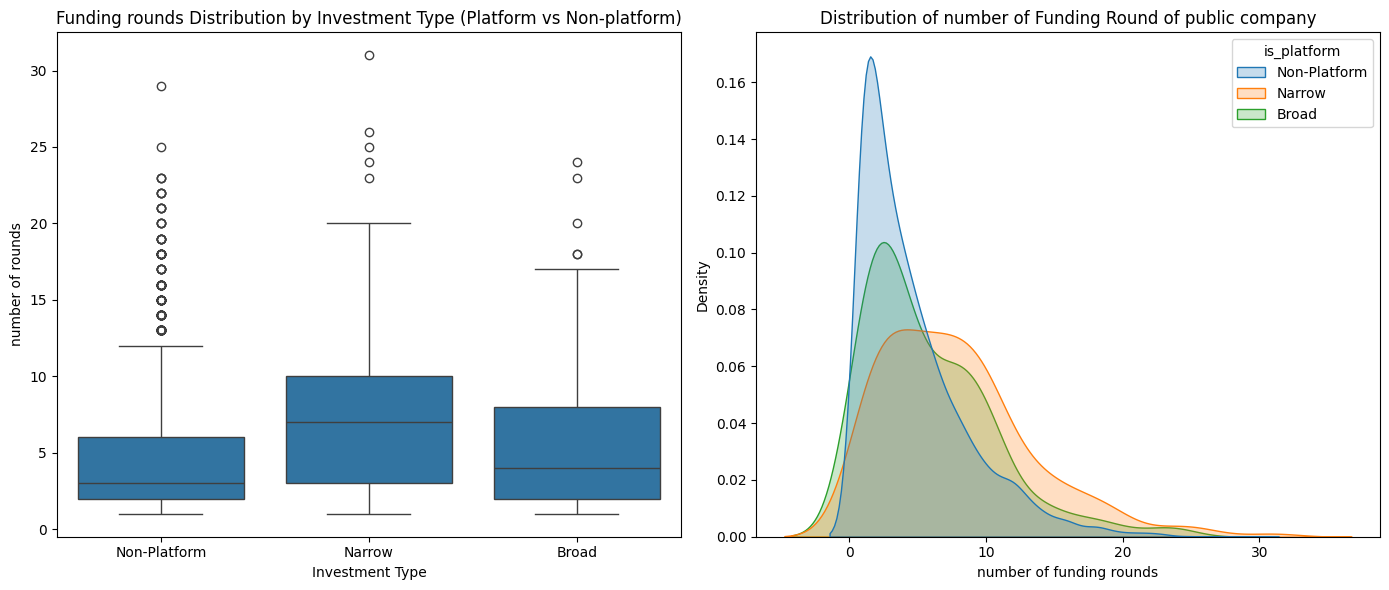

In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot ---
sns.boxplot(
    data=df_ipo,
    y='num_funding_rounds',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Funding rounds Distribution by Investment Type (Platform vs Non-platform)")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("number of rounds")

# --- KDE plot ---
sns.kdeplot(
    data=df_ipo,
    x='num_funding_rounds',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of number of Funding Round of public company")
axs[1].set_xlabel("number of funding rounds")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

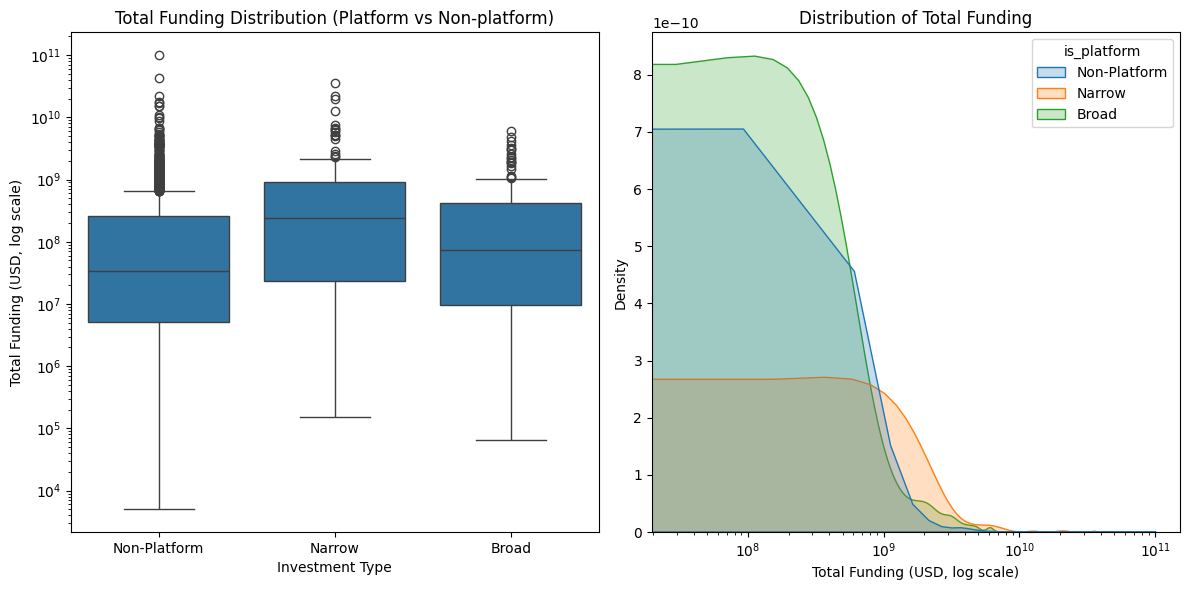

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Total Funding
# ---------------------------------------------------
sns.boxplot(
    data=df_ipo,
    y='total_funding_usd',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Total Funding Distribution (Platform vs Non-platform)")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Total Funding (USD, log scale)")
axs[0].set_yscale("log")          # Funding is usually very skewed

# ---------------------------------------------------
# 2) KDE PLOT — Total Funding
# ---------------------------------------------------
sns.kdeplot(
    data=df_ipo,
    x='total_funding_usd',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Total Funding")
axs[1].set_xlabel("Total Funding (USD, log scale)")
axs[1].set_ylabel("Density")
axs[1].set_xscale("log")          # KDE also needs log-scale

# ---------------------------------------------------
plt.tight_layout()
plt.show()

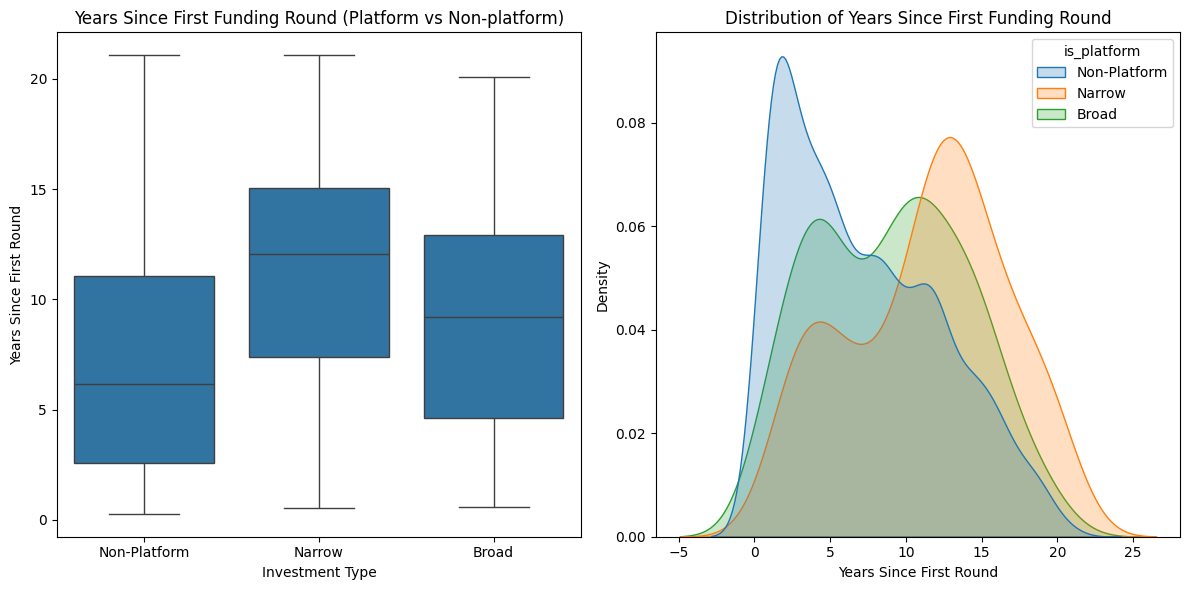

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Years Since First Round
# ---------------------------------------------------
sns.boxplot(
    data=df_ipo,
    y='years_since_first_round',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Years Since First Funding Round (Platform vs Non-platform)")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Years Since First Round")

# ---------------------------------------------------
# 2) KDE PLOT — Years Since First Round
# ---------------------------------------------------
sns.kdeplot(
    data=df_ipo,
    x='years_since_first_round',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Years Since First Funding Round")
axs[1].set_xlabel("Years Since First Round")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

Conditional on being acquired, what is the 
- Amount of funding,
- Number of funding rounds,
- Years since first round for platform vs. non-platform businesses?

In [ ]:
df_acquired = df_org_grouped[['uuid', 'name','short_description', 'created_at', 'status','company_age','num_funding_rounds', 'first_round_on','total_funding_usd', 'num_exits', 'is_inactive', 'is_vc_funded', 'is_platform', 'is_digital_nonplatform']].copy()
df_acquired = df_acquired[df_acquired['status']=='acquired']
df_acquired['years_since_first_round'] = ((today - df_acquired['first_round_on']).dt.days / 365)
platform_col = 'is_platform'

In [ ]:
df_acquired[platform_col].value_counts()

is_platform
Non-Platform    5786
Narrow          1493
Broad           1328
Name: count, dtype: int64

NameError: name 'df_acquired' is not defined

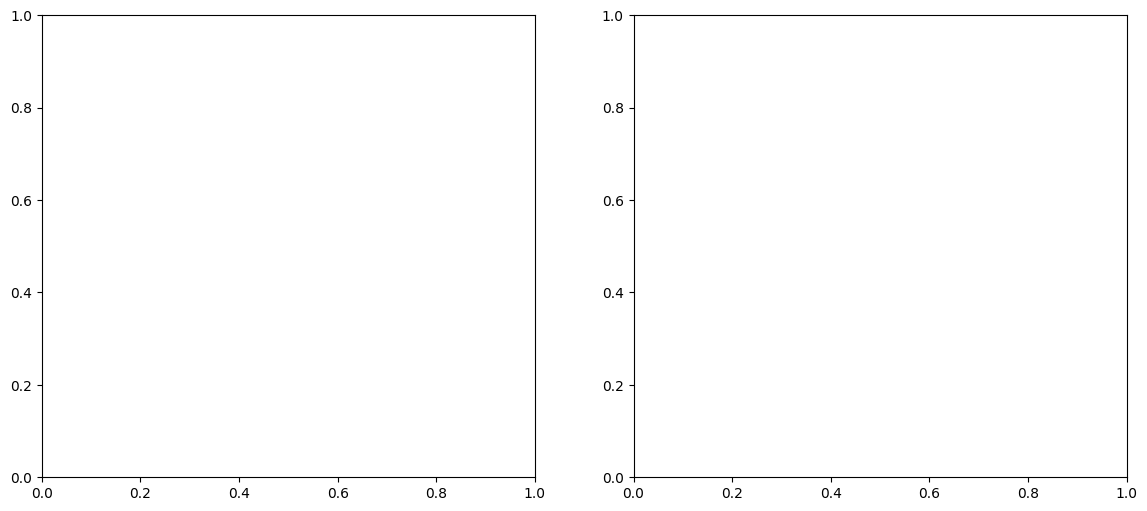

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot ---
sns.boxplot(
    data=df_acquired,
    y='num_funding_rounds',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Funding rounds Distribution by Investment Type (Platform vs Non-platform) for acquired companies")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("number of rounds")

# --- KDE plot ---
sns.kdeplot(
    data=df_acquired,
    x='num_funding_rounds',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of number of Funding Round of acquired company")
axs[1].set_xlabel("number of funding rounds")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

NameError: name 'df_acquired' is not defined

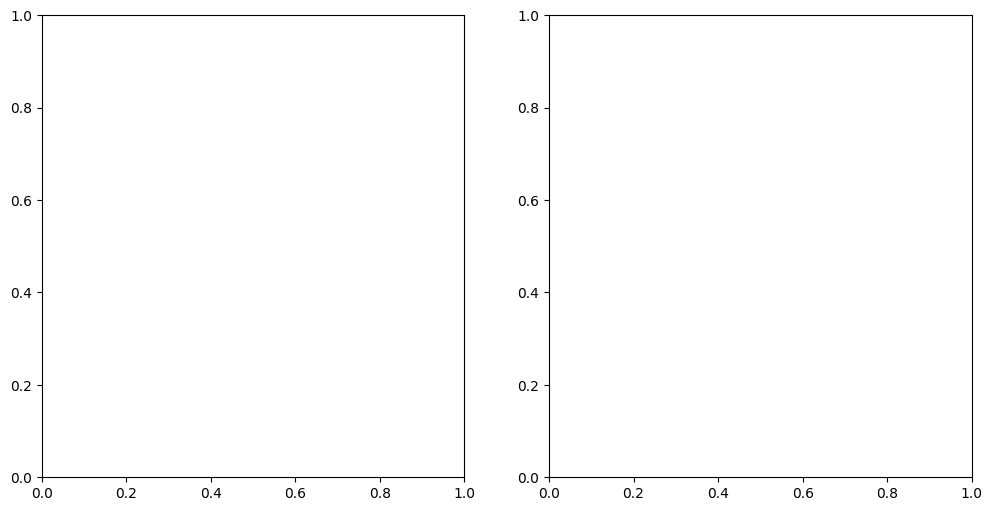

In [68]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Total Funding
# ---------------------------------------------------
sns.boxplot(
    data=df_acquired,
    y='total_funding_usd',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Total Funding Distribution (Platform vs Non-platform) for acquired companies")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Total Funding (USD, log scale)")
axs[0].set_yscale("log")          # Funding is usually very skewed

# ---------------------------------------------------
# 2) KDE PLOT — Total Funding
# ---------------------------------------------------
sns.kdeplot(
    data=df_acquired,
    x='total_funding_usd',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Total Funding for acquired companies")
axs[1].set_xlabel("Total Funding (USD, log scale)")
axs[1].set_ylabel("Density")
axs[1].set_xscale("log")          # KDE also needs log-scale

# ---------------------------------------------------
plt.tight_layout()
plt.show()

NameError: name 'df_acquired' is not defined

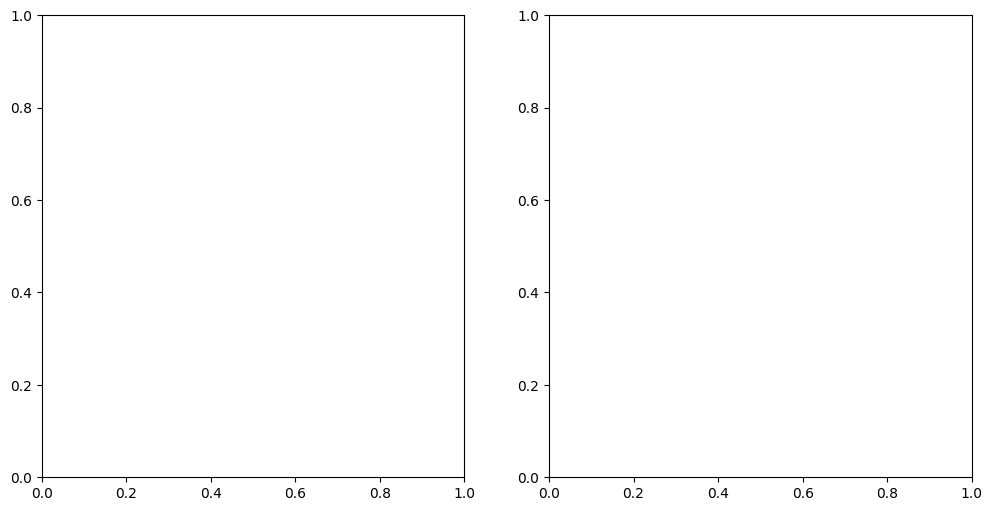

In [69]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---------------------------------------------------
# 1) BOX PLOT — Years Since First Round
# ---------------------------------------------------
sns.boxplot(
    data=df_acquired,
    y='years_since_first_round',
    x=platform_col,
    ax=axs[0]
)
axs[0].set_title("Years Since First Funding Round (Platform vs Non-platform) for acquired companies")
axs[0].set_xlabel("Investment Type")
axs[0].set_ylabel("Years Since First Round")

# ---------------------------------------------------
# 2) KDE PLOT — Years Since First Round
# ---------------------------------------------------
sns.kdeplot(
    data=df_acquired,
    x='years_since_first_round',
    hue=platform_col,
    fill=True,
    common_norm=False,
    ax=axs[1]
)
axs[1].set_title("Distribution of Years Since First Funding Round for acquired companies")
axs[1].set_xlabel("Years Since First Round")
axs[1].set_ylabel("Density")

plt.tight_layout()
plt.show()